In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from matplotlib.transforms import blended_transform_factory

In [2]:
def load_all_data_from_json(file_path):
    with open(file_path, "r") as file:
        data = json.load(file)
    return data

In [3]:
def load_values_from_json_without_normalization(file_path):
    with open(file_path, "r") as file:
        data_org = json.load(file)
    return list(data_org.values())
    #return [v for k, v in data_org.items() if "normalized" in k]

In [4]:
def load_values_from_json(file_path):
    with open(file_path, "r") as file:
        data_org = json.load(file)
    #return list(data_org.values())
    return [v for k, v in data_org.items() if "normalized" in k]

In [5]:
def get_files_with_cd(file_path, data_values, th):
    all_data = load_all_data_from_json(file_path)
    threshold = th
    keys_above_threshold = [key for key, value in all_data.items() if value > threshold]
    
    print(f"\nObjects whith Chamfer > {threshold}:")
    for key in keys_above_threshold:
        print(key)

    # Total number of files
    print(f"\nNumber of objects with Chamfer > {threshold}: {len(keys_above_threshold)} of {len(data_values)}")

In [6]:
def generate_histogram(data, bins, alpha, title, class_labels, means, colors):
    bins = 50
    plt.figure(figsize=(8, 4))

    all_data = np.concatenate(data)
    bin_edges = np.histogram_bin_edges(all_data, bins=bins)

    for i in range(len(data)):
        plt.hist(data[i], bins=bin_edges, alpha=alpha, color=colors[i], label=class_labels[i])
    for i in range(len(data)):    
        plt.axvline(means[i], color=colors[i], linestyle='--', linewidth=1.5, label=f"{class_labels[i]} Mean: {round(means[i], 3)}")

    # Add legend and labels
    plt.legend()
    plt.xlabel('Chamfer Distance Results')
    plt.ylabel('Frequency')
    plt.title(title)
    plt.show()

In [7]:
mpl.rcParams.update({
    'svg.fonttype': 'none',        # texto editable en SVG
    'pdf.fonttype': 42,            # texto como texto, no curvas
    'font.family': 'STIXGeneral',  # "Times-like" portátil
    'mathtext.fontset': 'stix'
})

In [8]:
def generate_histogram_and_save(data, g_class, bins, alpha, title, class_labels, means, colors, output_path):
    
    bins = 50
    plt.figure(figsize=(8, 5.3))

    all_data = np.concatenate(data)
    bin_edges = np.histogram_bin_edges(all_data, bins=bins)

    for i in range(len(data)):
        plt.hist(data[i], bins=bin_edges, alpha=alpha, color=colors[i], label=class_labels[i])
    for i in range(len(data)):    
        plt.axvline(means[i], color=colors[i], linestyle='--', linewidth=1.8, label=f"{class_labels[i]} Mean: {round(means[i], 3)}")
    
    # Set x-axis limits
    """ if g_class == 'chair':
        plt.xlim(0.000, 0.03)
        #plt.xticks(np.arange(0.0, 0.81, 0.09))
    else:
        plt.xlim(0.000, 0.03) """

    #plt.ylim(-0.01, 1000)

    # Add legend and labels
    plt.legend(frameon=True, framealpha=1.0)
    plt.xlabel('Chamfer Distance Results')
    plt.ylabel('Frequency')
    plt.title(title, pad=12 )
    plt.tight_layout()

    pdf_path = output_path.replace('.svg', '.pdf')
    plt.savefig(pdf_path, format='pdf', transparent=False)
    plt.show()
    plt.close()
    print(f"✅ Histograma guardado en: {output_path}")

In [9]:
def generate_histogram_and_save_with_means_old(data, bins, alpha, title, class_labels, means, colors, output_path, mean_labels=None):
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    })

    fig, ax = plt.subplots(figsize=(7.5, 4.5), facecolor="white")

    all_data = np.concatenate(data)
    bin_edges = np.histogram_bin_edges(all_data, bins=bins)

    # Histogramas más limpios
    for i in range(len(data)):
        ax.hist(
            data[i],
            bins=bin_edges,
            alpha=alpha,
            color=colors[i],
            edgecolor="none",
            histtype="stepfilled"
        )

    # Límite Y para posicionar las etiquetas
    ymax = ax.get_ylim()[1]

    # Pequeños offsets verticales para evitar que se monten
    y_positions = [0.92, 0.84, 0.76]

    for i in range(len(data)):
        # Línea vertical de la media
        ax.axvline(
            means[i],
            color=colors[i],
            linestyle="--",
            linewidth=1.8,
            zorder=3
        )

        # Etiqueta con fondo blanco
        ax.text(
            means[i],
            ymax * y_positions[i],
            mean_labels[i] + " = " + f"{means[i]:.4f}",
            color=colors[i],
            fontsize=12,
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.20",
                facecolor="white",
                edgecolor="none",
                alpha=0.95
            ),
            zorder=4
        )

    # Ejes
    ax.set_xlabel("Chamfer Distance")
    ax.set_ylabel("Frequency")
    ax.set_title(title, pad=12)

    # Estética más limpia
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Si quieres una grilla muy suave
    ax.grid(axis="y", alpha=0.12, linewidth=0.7)

    # Márgenes finos
    fig.subplots_adjust(top=0.88, bottom=0.16, left=0.10, right=0.97)

    pdf_path = output_path.replace(".svg", ".pdf")
    plt.savefig(pdf_path, format="pdf", transparent=False, bbox_inches="tight", pad_inches=0.03)
    plt.show()
    plt.close()

    print(f"✅ Histograma guardado en: {output_path}")

In [10]:
def generate_histogram_and_save_with_means(
    data,
    bins,
    alpha,
    title,
    class_labels,
    means,
    colors,
    output_path,
    mean_labels=None
):
    import numpy as np
    import matplotlib.pyplot as plt

    # =========================================================
    # 1) ESTILO GENERAL PARA PAPER
    # =========================================================
    text_col = "#0b1f3a"
    axis_col = "#5f6f7a"
    grid_col = "#d7e0e8"

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],

        # Tamaños aumentados para que no se vean pequeños en LaTeX
        "font.size": 18,
        "axes.titlesize": 20,
        "axes.labelsize": 20,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 15,

        "figure.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.facecolor": "white",

        "text.color": text_col,
        "axes.labelcolor": text_col,
        "xtick.color": text_col,
        "ytick.color": text_col,

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    if mean_labels is None:
        mean_labels = class_labels

    # =========================================================
    # 2) FIGURA
    # =========================================================
    fig, ax = plt.subplots(figsize=(9.2, 5.6), facecolor="white")

    all_data = np.concatenate(data)
    bin_edges = np.histogram_bin_edges(all_data, bins=bins)

    # =========================================================
    # 3) HISTOGRAMAS
    # =========================================================
    for i in range(len(data)):
        ax.hist(
            data[i],
            bins=bin_edges,
            alpha=alpha,
            color=colors[i],
            edgecolor="white",
            linewidth=0.35,
            histtype="stepfilled",
            label=class_labels[i],
            zorder=2
        )

    # =========================================================
    # 4) LÍNEAS DE MEDIA
    # =========================================================
    ymax = ax.get_ylim()[1]

    # Posiciones verticales más separadas para evitar superposición
    base_positions = [0.92, 0.81, 0.70, 0.59, 0.48]

    for i in range(len(data)):
        y_pos = base_positions[i] if i < len(base_positions) else 0.92 - i * 0.10

        ax.axvline(
            means[i],
            color=colors[i],
            linestyle="--",
            linewidth=2.3,
            alpha=0.95,
            zorder=4
        )

        ax.text(
            means[i],
            ymax * y_pos,
            f"{mean_labels[i]} = {means[i]:.4f}",
            color=colors[i],
            fontsize=16,
            fontweight="bold",
            ha="center",
            va="center",
            bbox=dict(
                boxstyle="round,pad=0.24",
                facecolor="white",
                edgecolor=colors[i],
                linewidth=0.8,
                alpha=0.96
            ),
            zorder=5
        )

    # =========================================================
    # 5) EJES Y TÍTULO
    # =========================================================
    ax.set_xlabel("NSCD", labelpad=10)
    ax.set_ylabel("Frequency", labelpad=10)

    ax.set_title(
        title,
        pad=14,
        loc="center",
        x=0.44
    )

    # =========================================================
    # 6) LEYENDA
    # =========================================================
    """ legend = ax.legend(
        loc="upper right",
        frameon=True,
        fancybox=False,
        borderpad=0.45,
        handlelength=1.7,
        labelspacing=0.35
    )

    legend.get_frame().set_facecolor("white")
    legend.get_frame().set_alpha(0.95)
    legend.get_frame().set_edgecolor("#c9d3dc")
    legend.get_frame().set_linewidth(0.8) """

    # =========================================================
    # 7) ESTÉTICA GENERAL
    # =========================================================
    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.75,
        color=grid_col,
        alpha=0.70,
        zorder=0
    )

    ax.set_axisbelow(True)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(axis_col)
        ax.spines[spine].set_linewidth(1.0)

    # Más espacio para título, ejes y etiquetas
    fig.subplots_adjust(
        top=0.88,
        bottom=0.17,
        left=0.13,
        right=0.96
    )

    # =========================================================
    # 8) GUARDADO
    # =========================================================
    if output_path.lower().endswith(".svg"):
        pdf_path = output_path[:-4] + ".pdf"

        plt.savefig(
            pdf_path,
            format="pdf",
            transparent=False,
            bbox_inches="tight",
            pad_inches=0.06
        )

        plt.savefig(
            output_path,
            format="svg",
            transparent=False,
            bbox_inches="tight",
            pad_inches=0.06
        )

        print(f"✅ Saved PDF: {pdf_path}")
        print(f"✅ Saved SVG: {output_path}")

    else:
        plt.savefig(
            output_path,
            transparent=False,
            bbox_inches="tight",
            pad_inches=0.06,
            dpi=400
        )

        print(f"✅ Saved figure: {output_path}")

    plt.show()
    plt.close()

In [11]:
def generate_heatmap_and_save_old(results, models, title, output_path, threshold_line=True):
    # =========================================================
    # 2) HISTOGRAMAS CON BINS COMUNES
    # =========================================================
    all_values = np.concatenate([np.asarray(results[m], dtype=float) for m in models])

    for m in models:
        for i in results[m]:
            if i >= 0.042:
                print(m, i)

    n_bins = 30
    bins = np.linspace(all_values.min(), all_values.max(), n_bins + 1)

    heatmap_data = []
    means = []

    for model in models:
        values = np.asarray(results[model], dtype=float)
        counts, _ = np.histogram(values, bins=bins)
        heatmap_data.append(counts)
        means.append(values.mean())

    heatmap_data = np.array(heatmap_data)
    means = np.array(means)

    # =========================================================
    # 3) THRESHOLD GLOBAL
    # =========================================================
    s_model_means = [means[i] for i, m in enumerate(models) if m.startswith("S-")]
    original_means = [means[i] for i, m in enumerate(models)
                    if (not m.startswith("S-")) and m != "ShapeNet"]

    threshold = means[0] #(np.mean(s_model_means) + np.mean(original_means)) / 2

    print(f"Media grupo S-models: {np.mean(s_model_means):.4f}")
    print(f"Media grupo originales: {np.mean(original_means):.4f}")
    print(f"Threshold: {threshold:.4f}")

    # =========================================================
    # 4) PALETA Y ESTILO
    # SOLO EL INTERIOR DEL HEATMAP TENDRÁ COLOR
    # =========================================================
    base_teal = "#0f2f33"
    panel_bg = "#f4f8f9"
    text_col = "#0b1f3a"
    line_col = "#1d4e89"

    teal_cmap = LinearSegmentedColormap.from_list(
        "teal_custom",
        [panel_bg, "#c7dcdf", "#8fbfc4", "#4a9aa4", base_teal]#["#f7fcf0", "#ccebc5", "#7bccc4", "#2b8cbe", "#084081"]#[panel_bg, "#d6e4f0", "#9fbfda", "#4f8fc0", base_teal]
    )

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "xtick.labelsize": 10,
        "ytick.labelsize": 11,
        "figure.facecolor": "white",   # FUERA de la figura en blanco
        "savefig.facecolor": "white",  # al guardar también blanco
        "axes.facecolor": "white",
        "text.color": text_col,
        "axes.labelcolor": text_col,
        "xtick.color": text_col,
        "ytick.color": text_col
    })

    # =========================================================
    # 5) FIGURA
    # =========================================================
    fig = plt.figure(figsize=(8, 5), facecolor="white")
    gs = fig.add_gridspec(
        1, 3,
        width_ratios=[18, 2.2, 0.55],
        wspace=0.08
    )

    ax = fig.add_subplot(gs[0, 0])
    ax_mean = fig.add_subplot(gs[0, 1], sharey=ax)
    cax = fig.add_subplot(gs[0, 2])

    # SOLO el heatmap interno lleva color
    ax.set_facecolor(panel_bg)

    # Mean CD y colorbar quedan blancos
    ax_mean.set_facecolor("white")
    cax.set_facecolor("white")

    # Normalización suave
    vmax = np.percentile(heatmap_data, 99.5)
    norm = PowerNorm(gamma=0.9, vmin=0, vmax=vmax)

    # =========================================================
    # 6) HEATMAP
    # =========================================================
    x_edges = bins
    y_edges = np.arange(len(models) + 1)

    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        heatmap_data,
        cmap=teal_cmap,
        norm=norm,
        shading="flat",
        edgecolors="none"
    )

    ax.set_ylim(0, len(models))
    ax.invert_yaxis()

    y_centers = np.arange(len(models)) + 0.5
    ax.set_yticks(y_centers)
    ax.set_yticklabels(models)

    # Línea de threshold
    if threshold_line == True:
        ax.axvline(
            threshold,
            color=line_col,
            linestyle=(0, (4, 3)),
            linewidth=1.2,
            alpha=0.95,
            zorder=2
        )

    # Marcas de media dentro del heatmap
    ax.scatter(
        means,
        y_centers,
        s=28,
        color=base_teal,
        edgecolor="#f7fbfc",
        linewidth=0.8,
        zorder=3
    )

    # Separadores horizontales suaves
    for y in range(1, len(models)):
        ax.hlines(y, bins[0], bins[-1], color="#f7fbfc", linewidth=0.8, alpha=0.45)

    # Bordes
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.set_title(title, pad=14, color=text_col)
    ax.set_xlabel("Chamfer Distance Results", labelpad=14)
    ax.set_ylabel("")

    # =========================================================
    # 7) COLUMNA DE MEDIAS
    # =========================================================
    ax_mean.set_xlim(0, 1)
    ax_mean.set_ylim(0, len(models))
    ax_mean.invert_yaxis()
    ax_mean.axis("off")

    ax_mean.text(
        0.06, -0.20,
        "Mean CD",
        ha="left", va="bottom",
        fontsize=11.5, fontweight="bold",
        color=base_teal
    )

    for y, mean_val in zip(y_centers, means):
        ax_mean.plot(
            [0.10, 0.10],
            [y - 0.14, y + 0.14],
            color=line_col,
            linewidth=1.6,
            solid_capstyle="round",
            zorder=2
        )

        ax_mean.scatter(
            0.10, y,
            s=36,
            color=base_teal,
            edgecolor="#f7fbfc",
            linewidth=0.7,
            zorder=3
        )

        ax_mean.text(
            0.24, y,
            f"{mean_val:.4f}",
            ha="left", va="center",
            fontsize=10.5,
            family="monospace",
            color=text_col
        )

    # =========================================================
    # 8) COLORBAR
    # =========================================================
    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label("Frequency", color=text_col, labelpad=8)
    cbar.ax.tick_params(colors=text_col)
    cbar.outline.set_linewidth(0.6)

    # =========================================================
    # 9) AJUSTE FINAL
    # =========================================================
    pdf_path = output_path.replace('.svg', '.pdf')

    fig.subplots_adjust(
        top=0.88,
        bottom=0.20,
        left=0.12,
        right=0.95
    )

    plt.savefig(pdf_path, format='pdf', transparent=False, bbox_inches='tight', pad_inches=0.06)
    plt.show()
    plt.close()
    print(f"✅ Histograma guardado en: {output_path}")

In [12]:
def generate_heatmap_and_save(
    results,
    models,
    title,
    output_path,
    threshold_line=True,
    show_title=False,
    show_colorbar=True
):
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap, PowerNorm
    from matplotlib.ticker import MaxNLocator

    # =========================================================
    # 1) HISTOGRAMAS CON BINS COMUNES
    # =========================================================
    all_values = np.concatenate([
        np.asarray(results[m], dtype=float) for m in models
    ])

    n_bins = 34
    bins = np.linspace(all_values.min(), all_values.max(), n_bins + 1)

    heatmap_data = []
    means = []

    for model in models:
        values = np.asarray(results[model], dtype=float)
        counts, _ = np.histogram(values, bins=bins)
        heatmap_data.append(counts)
        means.append(values.mean())

    heatmap_data = np.array(heatmap_data)
    means = np.array(means)

    threshold = means[0]

    # =========================================================
    # 2) ESTILO
    # =========================================================
    base_teal = "#0f2f33"
    panel_bg = "#f4f8f9"
    text_col = "#0b1f3a"
    axis_col = "#5f6f7a"
    line_col = "#1d4e89"

    mean_point_color = "#3f4a5a"
    mean_point_edge = "#ffffff"

    teal_cmap = LinearSegmentedColormap.from_list(
        "teal_custom",
        [
            panel_bg,
            "#c7dcdf",
            "#8fbfc4",
            "#4a9aa4",
            base_teal
        ]
    )

    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "DejaVu Serif"],

        "font.size": 18,
        "axes.titlesize": 18,
        "axes.labelsize": 18,
        "xtick.labelsize": 14,
        "ytick.labelsize": 15,

        "figure.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.facecolor": "white",

        "text.color": text_col,
        "axes.labelcolor": text_col,
        "xtick.color": text_col,
        "ytick.color": text_col,

        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    })

    # =========================================================
    # 3) FIGURA MÁS ALTA Y HEATMAP MÁS ANCHO
    # =========================================================
    if show_colorbar:
        fig = plt.figure(figsize=(7.2, 4.85), facecolor="white")

        gs = fig.add_gridspec(
            1, 4,
            # heatmap | Mean CD | espacio mínimo | colorbar
            width_ratios=[53.0, 14, 0, 1.5],
            wspace=0.045
        )

        ax = fig.add_subplot(gs[0, 0])

        # MODIFICADO:
        # No usar sharey=ax para evitar que Mean CD herede
        # los nombres de los modelos.
        ax_mean = fig.add_subplot(gs[0, 1])

        ax_space = fig.add_subplot(gs[0, 2])
        cax = fig.add_subplot(gs[0, 3])

        ax_space.axis("off")

    else:
        fig = plt.figure(figsize=(5.65, 4.25), facecolor="white")

        gs = fig.add_gridspec(
            1, 2,
            width_ratios=[23.0, 4.6],
            wspace=0.08
        )

        ax = fig.add_subplot(gs[0, 0])

        # MODIFICADO:
        # No usar sharey=ax.
        ax_mean = fig.add_subplot(gs[0, 1])

        cax = None

    ax.set_facecolor(panel_bg)
    ax_mean.set_facecolor("white")

    # =========================================================
    # 4) NORMALIZACIÓN
    # =========================================================
    vmax = np.percentile(heatmap_data, 99.5)

    if vmax <= 0:
        vmax = heatmap_data.max() if heatmap_data.max() > 0 else 1

    norm = PowerNorm(
        gamma=0.9,
        vmin=0,
        vmax=vmax
    )

    # =========================================================
    # 5) HEATMAP
    # =========================================================
    x_edges = bins
    y_edges = np.arange(len(models) + 1)

    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        heatmap_data,
        cmap=teal_cmap,
        norm=norm,
        shading="flat",
        edgecolors="none"
    )

    ax.set_ylim(0, len(models))
    ax.invert_yaxis()

    y_centers = np.arange(len(models)) + 0.5
    ax.set_yticks(y_centers)
    ax.set_yticklabels(models, fontsize=15)

    if threshold_line:
        ax.axvline(
            threshold,
            color=line_col,
            linestyle=(0, (4, 3)),
            linewidth=1.8,
            alpha=0.95,
            zorder=3
        )

    ax.scatter(
        means,
        y_centers,
        s=48,
        color=mean_point_color,
        edgecolor=mean_point_edge,
        linewidth=1.0,
        zorder=5
    )

    for y in range(1, len(models)):
        ax.hlines(
            y,
            bins[0],
            bins[-1],
            color="#f7fbfc",
            linewidth=0.9,
            alpha=0.50,
            zorder=2
        )

    # =========================================================
    # 6) EJES
    # =========================================================
    ax.set_xlabel(
        "NSCD",
        labelpad=9,
        fontsize=17
    )

    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=15)

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))

    if show_title:
        ax.set_title(
            title,
            pad=9,
            fontsize=17,
            color=text_col
        )

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(axis_col)
        ax.spines[spine].set_linewidth(0.9)

    # =========================================================
    # 7) COLUMNA MEAN CD SIN TEXTOS DE MODELOS
    # =========================================================
    ax_mean.set_xlim(0, 1)
    ax_mean.set_ylim(ax.get_ylim())

    # Apagar por completo ticks, labels y bordes
    ax_mean.set_xticks([])
    ax_mean.set_yticks([])
    ax_mean.tick_params(
        left=False,
        right=False,
        labelleft=False,
        labelright=False,
        bottom=False,
        top=False,
        labelbottom=False,
        labeltop=False
    )

    for spine in ax_mean.spines.values():
        spine.set_visible(False)

    ax_mean.set_facecolor("white")

    # x en coordenadas del eje, y en coordenadas de datos
    # Esto alinea punto, número y encabezado de forma estable
    mean_transform = blended_transform_factory(ax_mean.transAxes, ax_mean.transData)

    dot_x = 0.12
    value_x = 0.25
    header_x = 0.50

    ax_mean.text(
        header_x,
        1.025,
        "Mean NSCD",
        transform=ax_mean.transAxes,
        ha="center",
        va="bottom",
        fontsize=16.5,
        fontweight="bold",
        color=text_col,
        clip_on=False
    )

    for y, mean_val in zip(y_centers, means):
        ax_mean.scatter(
            dot_x,
            y,
            s=38,
            color=mean_point_color,
            edgecolor=mean_point_edge,
            linewidth=0.85,
            transform=mean_transform,
            zorder=4
        )

        ax_mean.text(
            value_x,
            y,
            f"{mean_val:.4f}",
            ha="left",
            va="center",
            fontsize=15.5,
            family="monospace",
            color=text_col,
            transform=mean_transform
        )

    # =========================================================
    # 8) COLORBAR MÁS SEPARADA
    # =========================================================
    if show_colorbar:
        cbar = fig.colorbar(mesh, cax=cax)

        cbar.set_label(
            "Frequency",
            color=text_col,
            labelpad=9,
            fontsize=14
        )

        cbar.ax.tick_params(
            colors=text_col,
            labelsize=13,
            width=0.7,
            length=3
        )

        cbar.outline.set_linewidth(0.6)
        cbar.outline.set_edgecolor(axis_col)

    # =========================================================
    # 9) AJUSTE FINAL
    # =========================================================
    fig.subplots_adjust(
        top=0.91 if not show_title else 0.84,
        bottom=0.18,
        left=0.13,
        right=0.98
    )

    # =========================================================
    # 10) GUARDADO
    # =========================================================
    if output_path.lower().endswith(".svg"):
        pdf_path = output_path[:-4] + ".pdf"

        plt.savefig(
            pdf_path,
            format="pdf",
            transparent=False,
            bbox_inches="tight",
            pad_inches=0.04
        )

        plt.savefig(
            output_path,
            format="svg",
            transparent=False,
            bbox_inches="tight",
            pad_inches=0.04
        )

        print(f"✅ Saved PDF: {pdf_path}")
        print(f"✅ Saved SVG: {output_path}")

    else:
        plt.savefig(
            output_path,
            transparent=False,
            bbox_inches="tight",
            pad_inches=0.04,
            dpi=400
        )

        print(f"✅ Saved figure: {output_path}")

    plt.show()
    plt.close()

    return heatmap_data, means

# ShapeNet 1000 Objects

## Centroid x = 0

1000
✅ Saved figure: original_shapenet.pdf


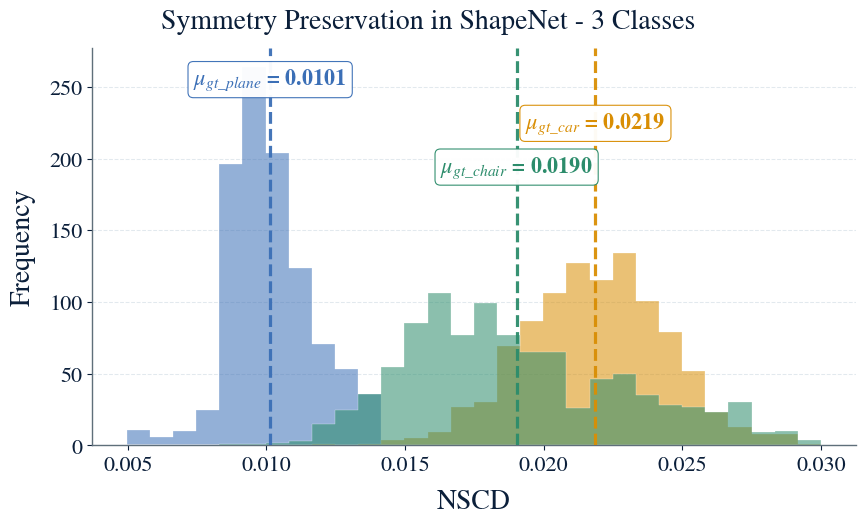

In [13]:
file_path_airplane = "/home/ncaytuir/data/Datasets/Scripts/Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/shapenet_airplane.json"
shapenet1000_airplane_data = load_values_from_json(file_path_airplane)  # Limiting to 405 samples
airplane_mean = np.mean(shapenet1000_airplane_data)
print(len(shapenet1000_airplane_data))

file_path_car = "/home/ncaytuir/data/Datasets/Scripts/Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/shapenet_car.json"
shapenet1000_car_data = load_values_from_json(file_path_car)  # Limiting to 405 samples
car_mean = np.mean(shapenet1000_car_data)

file_path_chair = "/home/ncaytuir/data/Datasets/Scripts/Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/shapenet_chair.json"
shapenet1000_chair_data = load_values_from_json(file_path_chair)  # Limiting to 405 samples
chair_mean = np.mean(shapenet1000_chair_data)

data = [shapenet1000_airplane_data, shapenet1000_car_data, shapenet1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [airplane_mean, car_mean, chair_mean]
colors = ["#3B6FB6", "#D98E04", "#2C8C6B"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

mean_labels = [
    r"$\mu_{gt\_{plane}}$",
    r"$\mu_{gt\_{car}}$",
    r"$\mu_{gt\_{chair}}$"
]

generate_histogram_and_save_with_means(data=data, bins=30, alpha=0.55, title="Symmetry Preservation in ShapeNet - 3 Classes", class_labels=class_labels, means=means, mean_labels=mean_labels, colors=colors, output_path="original_shapenet.pdf")

Mirrored objects

✅ Saved figure: mirrored_shapenet.pdf


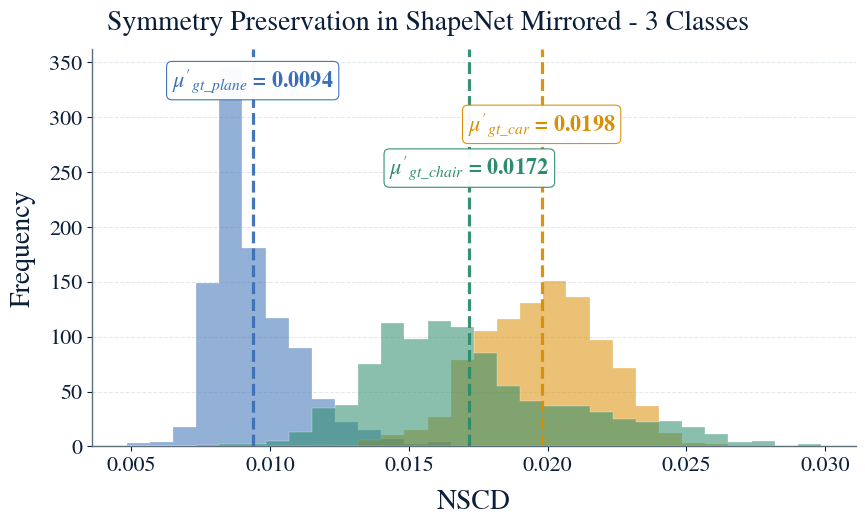

In [14]:
file_path_airplane = "/home/ncaytuir/data/Datasets/Scripts/Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/cd_res_mirrored_airplane.json"
mirrored_shapenet1000_airplane_data = load_values_from_json(file_path_airplane)
mirrored_airplane_mean = np.mean(mirrored_shapenet1000_airplane_data)

file_path_car = "/home/ncaytuir/data/Datasets/Scripts/Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/cd_res_mirrored_car.json"
mirrored_shapenet1000_car_data = load_values_from_json(file_path_car)
mirrored_car_mean = np.mean(mirrored_shapenet1000_car_data)

file_path_chair = "/home/ncaytuir/data/Datasets/Scripts/Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/cd_res_mirrored_chair.json"
mirrored_shapenet1000_chair_data = load_values_from_json(file_path_chair)
mirrored_chair_mean = np.mean(mirrored_shapenet1000_chair_data)

data = [mirrored_shapenet1000_airplane_data, mirrored_shapenet1000_car_data, mirrored_shapenet1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [mirrored_airplane_mean, mirrored_car_mean, mirrored_chair_mean]
colors = ["#3B6FB6", "#D98E04", "#2C8C6B"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

mean_labels = [
    r"$\mu'_{gt\_{plane}}$",
    r"$\mu'_{gt\_{car}}$",
    r"$\mu'_{gt\_{chair}}$"
]

generate_histogram_and_save_with_means(data=data, bins=30, alpha=0.55, title="Symmetry Preservation in ShapeNet Mirrored - 3 Classes", class_labels=class_labels, means=means, mean_labels=mean_labels, colors=colors, output_path="mirrored_shapenet.pdf")

# DPM

## Original CKPT

0.015575944512178006
0.030150024251791238
0.02800921168497784
1000


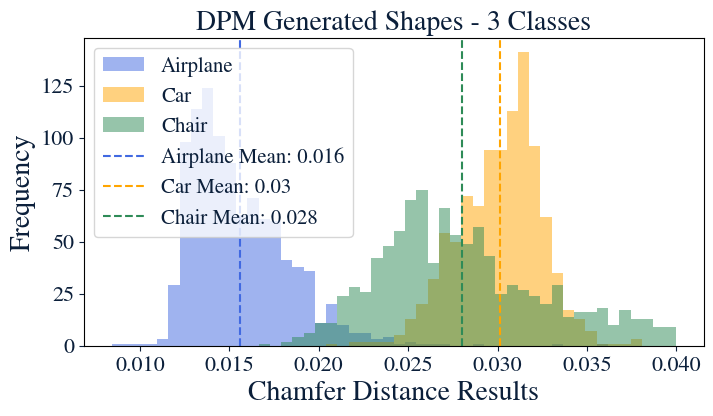

In [15]:
file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_original_dpm_cd_results_airplane.json"
dpm_airplane_data = load_values_from_json(file_path)  # Limiting to 404 samples
dpm_original_airplane_mean = np.mean(dpm_airplane_data)
print(dpm_original_airplane_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_original_dpm_cd_results_car.json"
dpm_car_data = load_values_from_json(file_path)  # Limiting to 346 samples
dpm_original_car_mean = np.mean(dpm_car_data)
print(dpm_original_car_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_original_dpm_cd_results_chair.json"
dpm_chair_data = load_values_from_json(file_path)  # Limiting to 637 samples
dpm_original_chair_mean = np.mean(dpm_chair_data)
print(dpm_original_chair_mean)

print(len(dpm_chair_data))

data = [dpm_airplane_data, dpm_car_data, dpm_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [dpm_original_airplane_mean, dpm_original_car_mean, dpm_original_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="DPM Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [16]:
print(abs(airplane_mean - dpm_original_airplane_mean))
print(abs(airplane_mean - dpm_original_airplane_mean)*100)

0.005441704230866189
0.5441704230866189


In [17]:
print(abs(car_mean - dpm_original_car_mean))
print(abs(car_mean - dpm_original_car_mean)*100)

0.008285919986634662
0.8285919986634662


In [18]:
print(abs(chair_mean - dpm_original_chair_mean))
print(abs(chair_mean - dpm_original_chair_mean)*100)

0.008987406437107957
0.8987406437107958


Mirrored Objects

0.015769270957855838
0.031051343944852216
0.028925145094691948


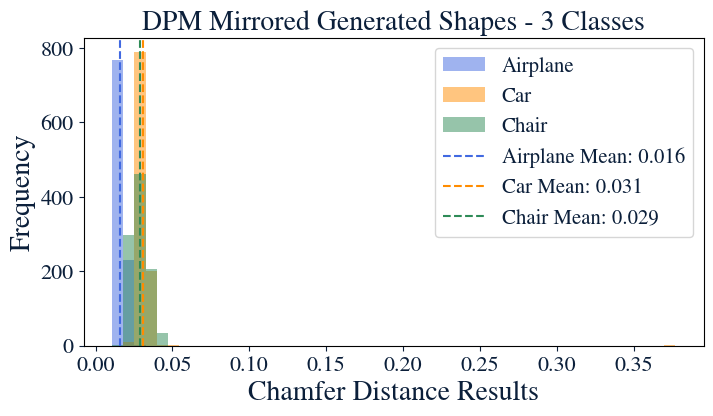

In [19]:
file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_dpm_cd_results_airplane.json"
dpm_mirrored_airplane_data = load_values_from_json(file_path)  # Limiting to 404 samples
dpm_mirrored_airplane_mean = np.mean(dpm_mirrored_airplane_data)
print(dpm_mirrored_airplane_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_dpm_cd_results_car.json"
dpm_mirrored_car_data = load_values_from_json(file_path)  # Limiting to 346 samples
dpm_mirrored_car_mean = np.mean(dpm_mirrored_car_data)
print(dpm_mirrored_car_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_dpm_cd_results_chair.json"
dpm_mirrored_chair_data = load_values_from_json(file_path)  # Limiting to 637 samples
dpm_mirrored_chair_mean = np.mean(dpm_mirrored_chair_data)
print(dpm_mirrored_chair_mean)

data = [dpm_mirrored_airplane_data, dpm_mirrored_car_data, dpm_mirrored_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [dpm_mirrored_airplane_mean, dpm_mirrored_car_mean, dpm_mirrored_chair_mean]
colors = ["royalblue", "darkorange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="DPM Mirrored Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [20]:
print(abs(mirrored_airplane_mean - dpm_mirrored_airplane_mean))
print(abs(mirrored_airplane_mean - dpm_mirrored_airplane_mean)*100)

0.006400711253976116
0.6400711253976116


In [21]:
print(abs(mirrored_car_mean - dpm_mirrored_car_mean))
print(abs(mirrored_car_mean - dpm_mirrored_car_mean)*100)

0.011267304915363322
1.1267304915363323


In [22]:
print(abs(mirrored_chair_mean - dpm_mirrored_chair_mean))
print(abs(mirrored_chair_mean - dpm_mirrored_chair_mean)*100)

0.011747035062468682
1.1747035062468683


## Over Half Objects

### Airplane

In [23]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/_new_exp_dpm_cd_results_airplane.json"
s_dpm_airplane_data = load_values_from_json(file_path)
s_dpm_airplane_mean = np.mean(s_dpm_airplane_data)

data = [s_dpm_airplane_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["Airplane"] # , "Car", "Chair"
means = [s_dpm_airplane_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Airplane", class_labels=class_labels, means=means, colors=colors)

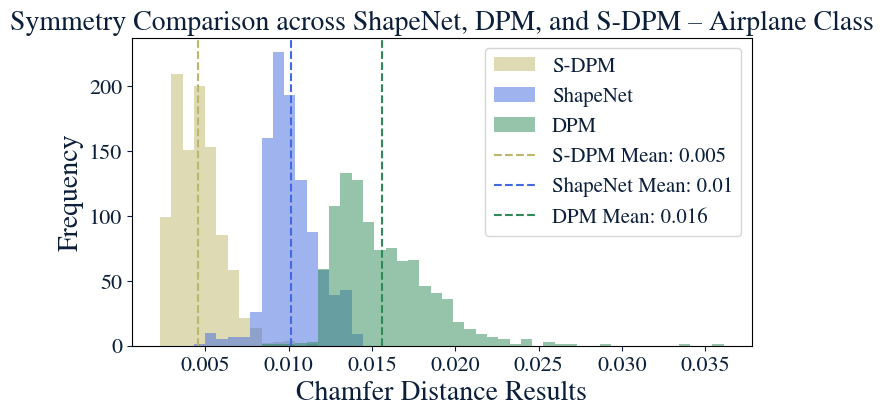

In [24]:
data = [s_dpm_airplane_data, shapenet1000_airplane_data, dpm_airplane_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-DPM", "ShapeNet", "DPM"] # , "Car", "Chair"
means = [s_dpm_airplane_mean, airplane_mean, dpm_original_airplane_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, DPM, and S-DPM – Airplane Class", class_labels=class_labels, means=means, colors=colors)

### Car

In [25]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/_new_exp_dpm_cd_results_car.json"
s_dpm_car_data = load_values_from_json(file_path)
s_dpm_car_mean = np.mean(s_dpm_car_data)

data = [s_dpm_airplane_data]
class_labels = ["Car"]
means = [s_dpm_car_mean]
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Car", class_labels=class_labels, means=means, colors=colors)

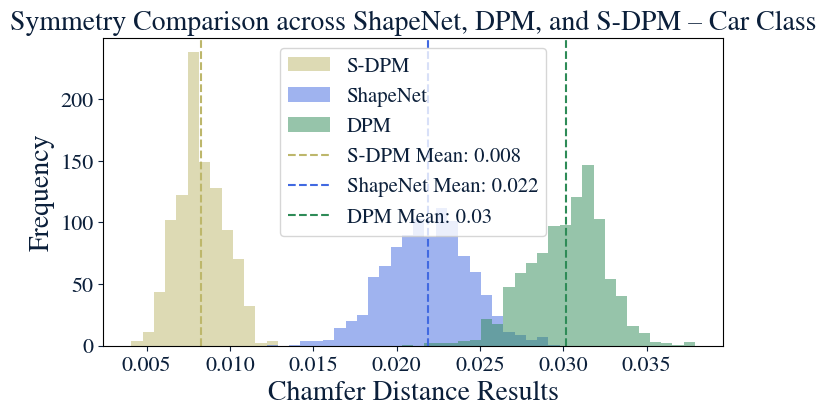

In [26]:
data = [s_dpm_car_data, shapenet1000_car_data, dpm_car_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-DPM", "ShapeNet", "DPM"] # , "Car", "Chair"
means = [s_dpm_car_mean, car_mean, dpm_original_car_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, DPM, and S-DPM – Car Class", class_labels=class_labels, means=means, colors=colors)

### Chair

In [27]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/_new_exp_dpm_cd_results_chair.json"
s_dpm_chair_data = load_values_from_json(file_path)
s_dpm_chair_mean = np.mean(s_dpm_chair_data)

data = [s_dpm_chair_data]
class_labels = ["Chair"]
means = [s_dpm_chair_mean] 
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Chair", class_labels=class_labels, means=means, colors=colors)

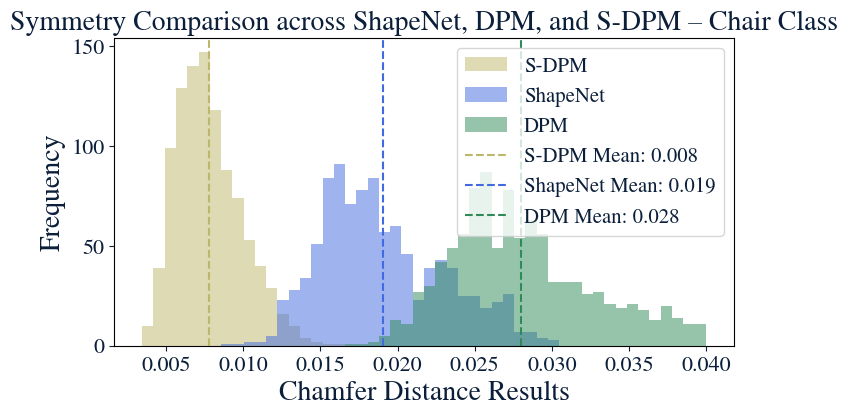

In [28]:
data = [s_dpm_chair_data, shapenet1000_chair_data, dpm_chair_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-DPM", "ShapeNet", "DPM"] # , "Chair", "Chair"
means = [s_dpm_chair_mean, chair_mean, dpm_original_chair_mean] # , pvd_Chair_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, DPM, and S-DPM – Chair Class", class_labels=class_labels, means=means, colors=colors)

# PVD

## Original CKPT

0.015457461477592553
0.029721442564253436
0.027848345414865527
1000


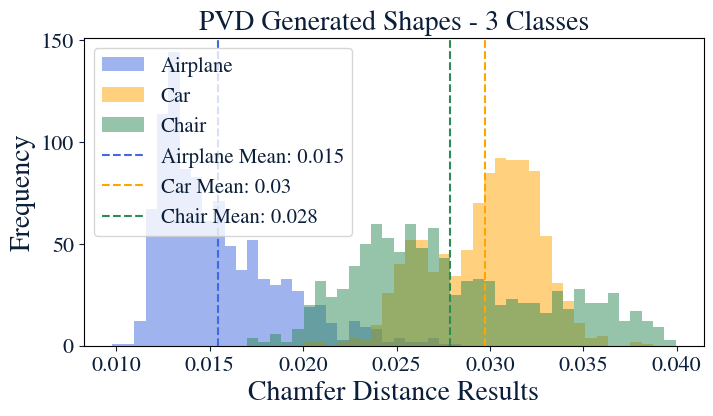

In [29]:
file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/centered_pvd_cd_results_airplane.json"
pvd1000_airplane_data = load_values_from_json(file_path)  # Limiting to 404 samples
pvd_original_airplane_mean = np.mean(pvd1000_airplane_data)
print(pvd_original_airplane_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/centered_pvd_cd_results_car.json"
pvd1000_car_data = load_values_from_json(file_path)  # Limiting to 346 samples
pvd_original_car_mean = np.mean(pvd1000_car_data)
print(pvd_original_car_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/centered_pvd_cd_results_chair.json"
pvd1000_chair_data = load_values_from_json(file_path)  # Limiting to 637 samples
pvd_original_chair_mean = np.mean(pvd1000_chair_data)
print(pvd_original_chair_mean)

print(len(pvd1000_chair_data))

data = [pvd1000_airplane_data, pvd1000_car_data, pvd1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [pvd_original_airplane_mean, pvd_original_car_mean, pvd_original_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [30]:
print(abs(airplane_mean - pvd_original_airplane_mean))
print(abs(airplane_mean - pvd_original_airplane_mean)*100)

0.005323221196280736
0.5323221196280736


In [31]:
print(abs(car_mean - pvd_original_car_mean))
print(abs(car_mean - pvd_original_car_mean)*100)

0.00785733829909686
0.785733829909686


In [32]:
print(abs(chair_mean - pvd_original_chair_mean))
print(abs(chair_mean - pvd_original_chair_mean)*100)

0.008826540166995644
0.8826540166995643


Mirrored Objects

0.015469059833162411
0.02961724779826108
0.02752990368102717


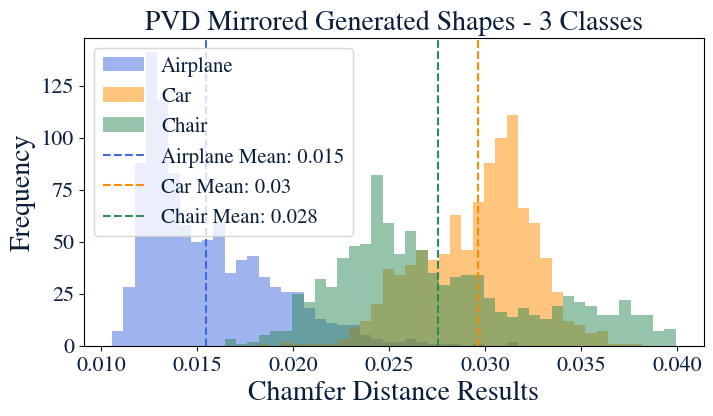

In [33]:
file_path = "/home/ncaytuir/data/Datasets/Scripts/Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_pvd_cd_results_airplane.json"
pvd_mirrored_airplane_data = load_values_from_json(file_path)  # Limiting to 404 samples
pvd_mirrored_airplane_mean = np.mean(pvd_mirrored_airplane_data)
print(pvd_mirrored_airplane_mean)

file_path = "/home/ncaytuir/data/Datasets/Scripts/Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_pvd_cd_results_car.json"
pvd_mirrored_car_data = load_values_from_json(file_path)  # Limiting to 346 samples
pvd_mirrored_car_mean = np.mean(pvd_mirrored_car_data)
print(pvd_mirrored_car_mean)

file_path = "/home/ncaytuir/data/Datasets/Scripts/Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_pvd_cd_results_chair.json"
pvd_mirrored_chair_data = load_values_from_json(file_path)  # Limiting to 637 samples
pvd_mirrored_chair_mean = np.mean(pvd_mirrored_chair_data)
print(pvd_mirrored_chair_mean)

data = [pvd_mirrored_airplane_data, pvd_mirrored_car_data, pvd_mirrored_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [pvd_mirrored_airplane_mean, pvd_mirrored_car_mean, pvd_mirrored_chair_mean]
colors = ["royalblue", "darkorange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Mirrored Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [34]:
print(abs(mirrored_airplane_mean - pvd_mirrored_airplane_mean))
print(abs(mirrored_airplane_mean - pvd_mirrored_airplane_mean)*100)

0.006100500129282689
0.6100500129282689


In [35]:
print(abs(mirrored_car_mean - pvd_mirrored_car_mean))
print(abs(mirrored_car_mean - pvd_mirrored_car_mean)*100)

0.009833208768772188
0.9833208768772188


In [36]:
print(abs(mirrored_chair_mean - pvd_mirrored_chair_mean))
print(abs(mirrored_chair_mean - pvd_mirrored_chair_mean)*100)

0.010351793648803904
1.0351793648803904


## Over Half Objects

### Airplane

In [37]:
file_path = "/home/ncaytuir/data/Datasets/Scripts/Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/cd_res_PVD_airplane.json"
s_pvd_airplane_data = load_values_from_json(file_path)
s_pvd_airplane_mean = np.mean(s_pvd_airplane_data)

data = [s_pvd_airplane_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["Airplane"] # , "Car", "Chair"
means = [s_pvd_airplane_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Airplane", class_labels=class_labels, means=means, colors=colors)

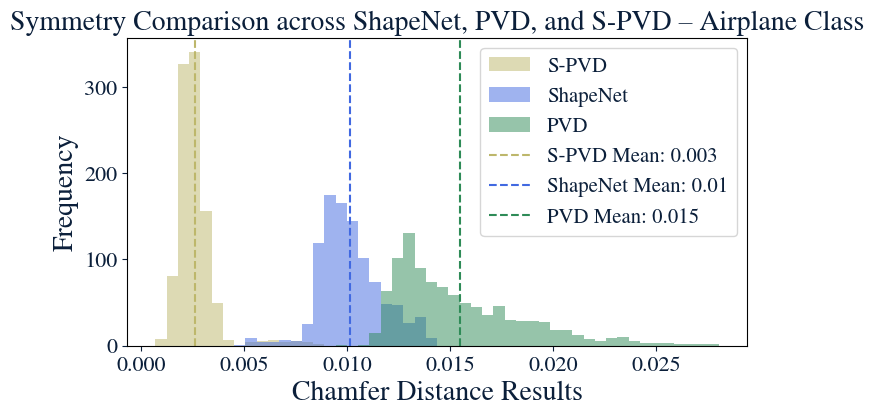

In [38]:
data = [s_pvd_airplane_data, shapenet1000_airplane_data, pvd1000_airplane_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-PVD", "ShapeNet", "PVD"] # , "Car", "Chair"
means = [s_pvd_airplane_mean, airplane_mean, pvd_original_airplane_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, PVD, and S-PVD – Airplane Class", class_labels=class_labels, means=means, colors=colors)

### Car

In [39]:
file_path = "/home/ncaytuir/data/Datasets/Scripts/Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/cd_res_PVD_car.json"
s_pvd_car_data = load_values_from_json(file_path)
s_pvd_car_mean = np.mean(s_pvd_car_data)

data = [s_pvd_car_data]
class_labels = ["Car"]
means = [s_pvd_car_mean]
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Car", class_labels=class_labels, means=means, colors=colors)

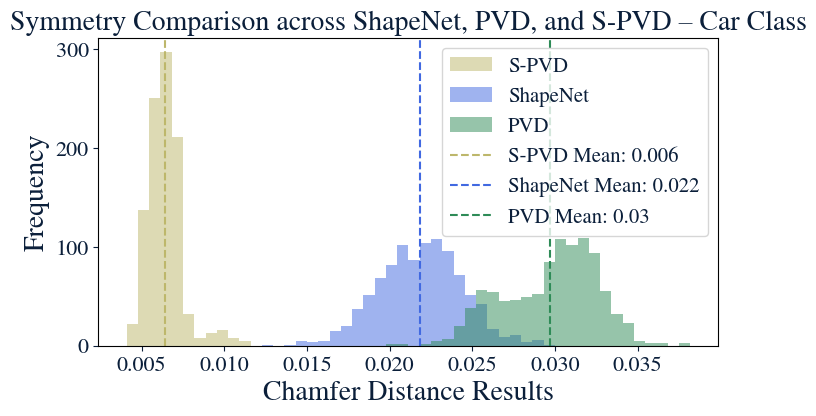

In [40]:
data = [s_pvd_car_data, shapenet1000_car_data, pvd1000_car_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-PVD", "ShapeNet", "PVD"] # , "Car", "Chair"
means = [s_pvd_car_mean, car_mean, pvd_original_car_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, PVD, and S-PVD – Car Class", class_labels=class_labels, means=means, colors=colors)

### Chair

In [41]:
file_path = "/home/ncaytuir/data/Datasets/Scripts/Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/cd_res_PVD_chair.json"
s_pvd_chair_data = load_values_from_json(file_path)
s_pvd_chair_mean = np.mean(s_pvd_chair_data)

data = [s_pvd_chair_data]
class_labels = ["Chair"]
means = [s_pvd_chair_mean] 
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Chair", class_labels=class_labels, means=means, colors=colors)

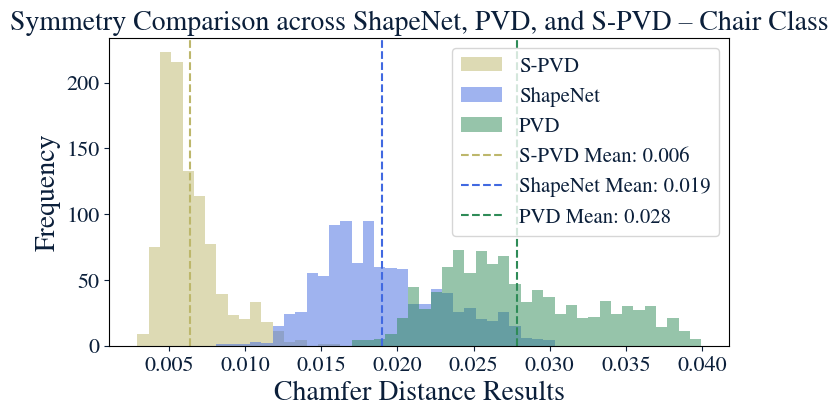

In [42]:
data = [s_pvd_chair_data, shapenet1000_chair_data, pvd1000_chair_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-PVD", "ShapeNet", "PVD"] # , "Chair", "Chair"
means = [s_pvd_chair_mean, chair_mean, pvd_original_chair_mean] # , pvd_Chair_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, PVD, and S-PVD – Chair Class", class_labels=class_labels, means=means, colors=colors)

# SPVD-S

## Original CKPT

0.028910096060629484
0.0287619162234473
0.02865996654237172
1000


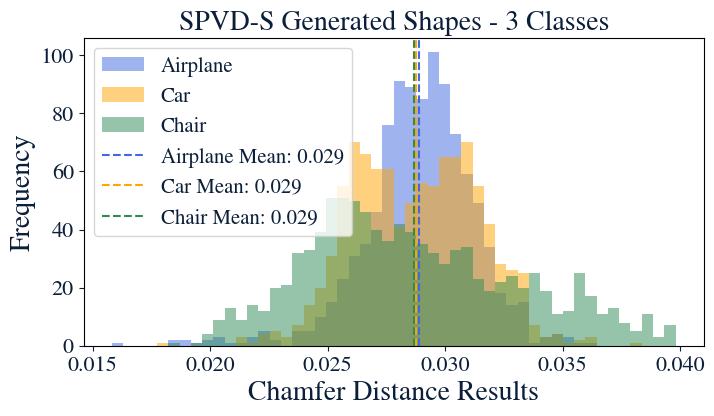

In [43]:
file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_original_spvd-s_cd_results_airplane.json"
spvd_s_airplane_data = load_values_from_json(file_path)  # Limiting to 404 samples
spvd_s_original_airplane_mean = np.mean(spvd_s_airplane_data)
print(spvd_s_original_airplane_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_original_spvd-s_cd_results_car.json"
spvd_s_car_data = load_values_from_json(file_path)  # Limiting to 346 samples
spvd_s_original_car_mean = np.mean(spvd_s_car_data)
print(spvd_s_original_car_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_original_spvd-s_cd_results_chair.json"
spvd_s_chair_data = load_values_from_json(file_path)  # Limiting to 637 samples
spvd_s_original_chair_mean = np.mean(spvd_s_chair_data)
print(spvd_s_original_chair_mean)

print(len(spvd_s_chair_data))

data = [spvd_s_airplane_data, spvd_s_car_data, spvd_s_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [spvd_s_original_airplane_mean, spvd_s_original_car_mean, spvd_s_original_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="SPVD-S Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [44]:
print(abs(airplane_mean - spvd_s_original_airplane_mean))
print(abs(airplane_mean - spvd_s_original_airplane_mean)*100)

0.018775855779317667
1.8775855779317667


In [45]:
print(abs(car_mean - spvd_s_original_car_mean))
print(abs(car_mean - spvd_s_original_car_mean)*100)

0.006897811958290725
0.6897811958290725


In [46]:
print(abs(chair_mean - spvd_s_original_chair_mean))
print(abs(chair_mean - spvd_s_original_chair_mean)*100)

0.009638161294501835
0.9638161294501836


Mirrored Objects

0.018776597003336632
0.03147661625355243
0.03011762814069772


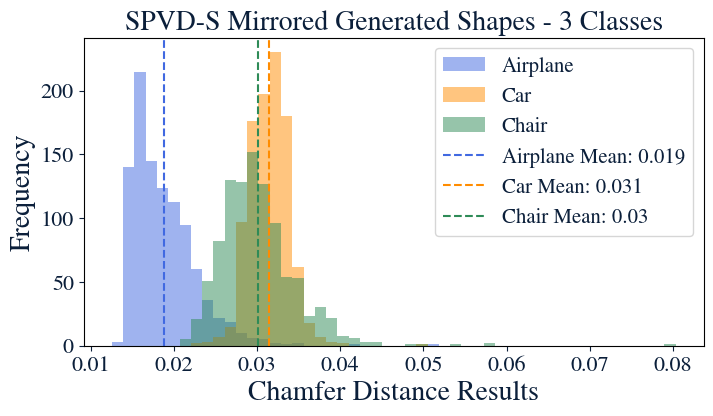

In [47]:
file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_spvd-s_cd_results_airplane.json"
spvd_s_mirrored_airplane_data = load_values_from_json(file_path)  # Limiting to 404 samples
spvd_s_mirrored_airplane_mean = np.mean(spvd_s_mirrored_airplane_data)
print(spvd_s_mirrored_airplane_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_spvd-s_cd_results_car.json"
spvd_s_mirrored_car_data = load_values_from_json(file_path)  # Limiting to 346 samples
spvd_s_mirrored_car_mean = np.mean(spvd_s_mirrored_car_data)
print(spvd_s_mirrored_car_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_spvd-s_cd_results_chair.json"
spvd_s_mirrored_chair_data = load_values_from_json(file_path)  # Limiting to 637 samples
spvd_s_mirrored_chair_mean = np.mean(spvd_s_mirrored_chair_data)
print(spvd_s_mirrored_chair_mean)

data = [spvd_s_mirrored_airplane_data, spvd_s_mirrored_car_data, spvd_s_mirrored_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [spvd_s_mirrored_airplane_mean, spvd_s_mirrored_car_mean, spvd_s_mirrored_chair_mean]
colors = ["royalblue", "darkorange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="SPVD-S Mirrored Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [48]:
print(abs(mirrored_airplane_mean - spvd_s_mirrored_airplane_mean))
print(abs(mirrored_airplane_mean - spvd_s_mirrored_airplane_mean)*100)

0.00940803729945691
0.940803729945691


In [49]:
print(abs(mirrored_car_mean - spvd_s_mirrored_car_mean))
print(abs(mirrored_car_mean - spvd_s_mirrored_car_mean)*100)

0.011692577224063534
1.1692577224063534


In [50]:
print(abs(mirrored_chair_mean - spvd_s_mirrored_chair_mean))
print(abs(mirrored_chair_mean - spvd_s_mirrored_chair_mean)*100)

0.012939518108474456
1.2939518108474455


## Over Half Objects

### Airplane

In [51]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/_new_exp_over-half_spvd_s_cd_results_airplane.json"
s_spvd_s_airplane_data = load_values_from_json(file_path)
s_spvd_s_airplane_mean = np.mean(s_spvd_s_airplane_data)

data = [s_spvd_s_airplane_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["Airplane"] # , "Car", "Chair"
means = [s_spvd_s_airplane_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Airplane", class_labels=class_labels, means=means, colors=colors)

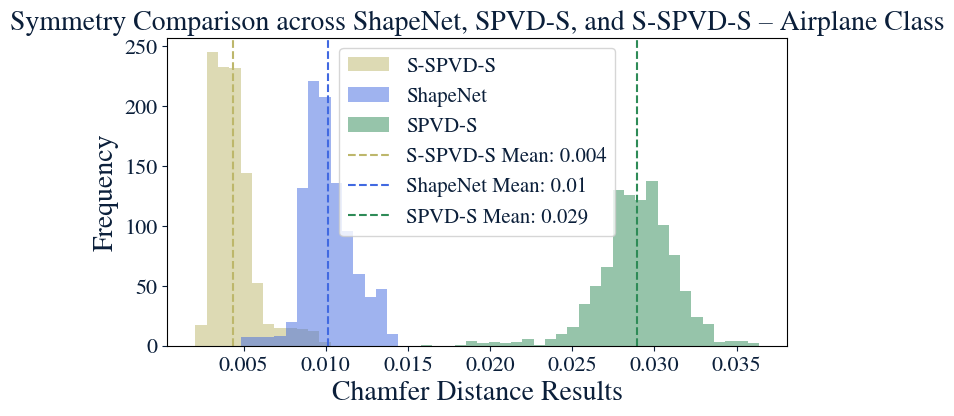

In [52]:
data = [s_spvd_s_airplane_data, shapenet1000_airplane_data, spvd_s_airplane_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-SPVD-S", "ShapeNet", "SPVD-S"] # , "Car", "Chair"
means = [s_spvd_s_airplane_mean, airplane_mean, spvd_s_original_airplane_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, SPVD-S, and S-SPVD-S – Airplane Class", class_labels=class_labels, means=means, colors=colors)

### Car

In [53]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/_new_exp_over-half_spvd_s_cd_results_car.json"
s_spvd_s_car_data = load_values_from_json(file_path)
s_spvd_s_car_mean = np.mean(s_spvd_s_car_data)

data = [s_spvd_s_airplane_data]
class_labels = ["Car"]
means = [s_spvd_s_car_mean]
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Car", class_labels=class_labels, means=means, colors=colors)

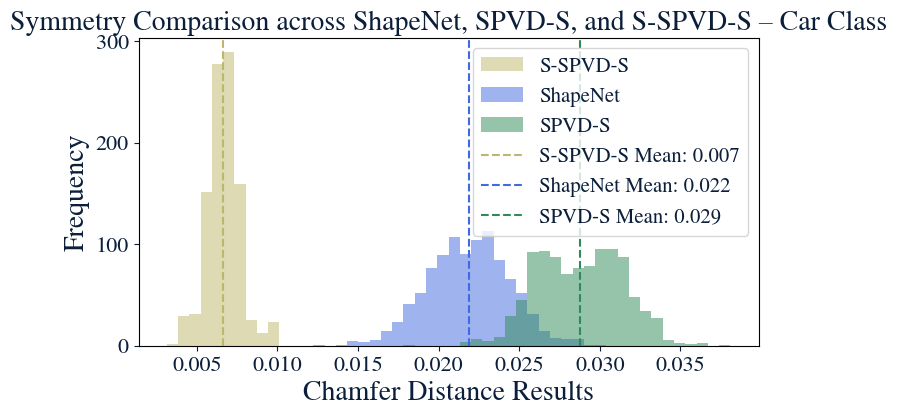

In [54]:
data = [s_spvd_s_car_data, shapenet1000_car_data, spvd_s_car_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-SPVD-S", "ShapeNet", "SPVD-S"] # , "Car", "Chair"
means = [s_spvd_s_car_mean, car_mean, spvd_s_original_car_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, SPVD-S, and S-SPVD-S – Car Class", class_labels=class_labels, means=means, colors=colors)

### Chair

In [55]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/_new_exp_over-half_spvd_s_cd_results_chair.json"
s_spvd_s_chair_data = load_values_from_json(file_path)
s_spvd_s_chair_mean = np.mean(s_spvd_s_chair_data)

data = [s_spvd_s_chair_data]
class_labels = ["Chair"]
means = [s_spvd_s_chair_mean] 
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Chair", class_labels=class_labels, means=means, colors=colors)

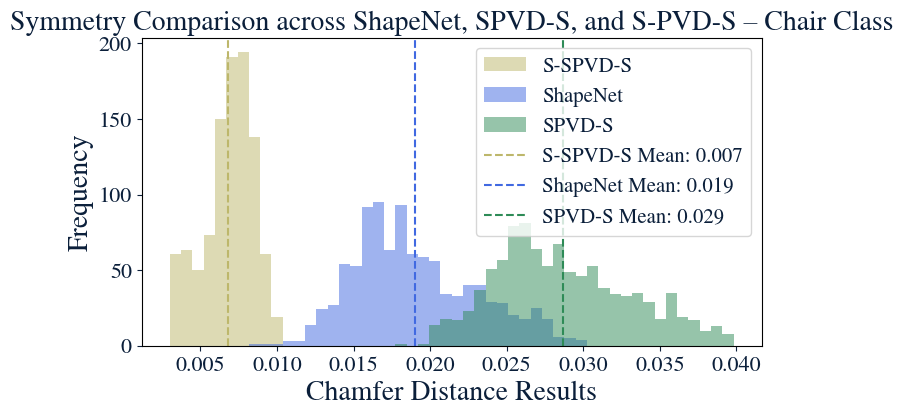

In [56]:
data = [s_spvd_s_chair_data, shapenet1000_chair_data, spvd_s_chair_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-SPVD-S", "ShapeNet", "SPVD-S"] # , "Chair", "Chair"
means = [s_spvd_s_chair_mean, chair_mean, spvd_s_original_chair_mean] # , pvd_Chair_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, SPVD-S, and S-PVD-S – Chair Class", class_labels=class_labels, means=means, colors=colors)

# SPVD-L

## Original CKPT

0.028311924888055336
0.02755892642065792
0.029184919569225008
1000


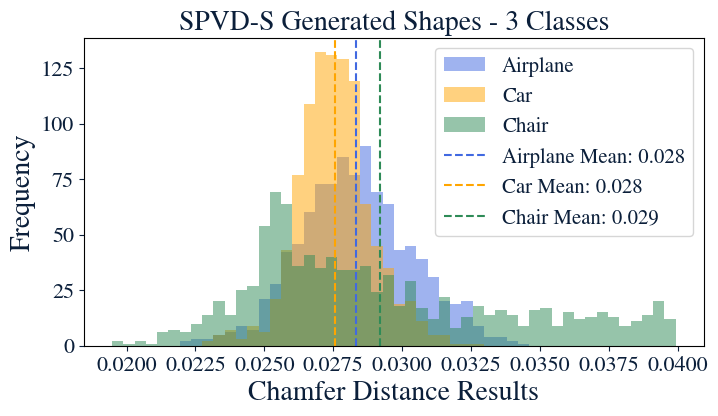

In [57]:
file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_original_spvd-l_cd_results_airplane.json"
spvd_l_airplane_data = load_values_from_json(file_path)  # Limiting to 404 samples
spvd_l_original_airplane_mean = np.mean(spvd_l_airplane_data)
print(spvd_l_original_airplane_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_original_spvd-l_cd_results_car.json"
spvd_l_car_data = load_values_from_json(file_path)  # Limiting to 346 samples
spvd_l_original_car_mean = np.mean(spvd_l_car_data)
print(spvd_l_original_car_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_original_spvd-l_cd_results_chair.json"
spvd_l_chair_data = load_values_from_json(file_path)  # Limiting to 637 samples
spvd_l_original_chair_mean = np.mean(spvd_l_chair_data)
print(spvd_l_original_chair_mean)

print(len(spvd_l_chair_data))

data = [spvd_l_airplane_data, spvd_l_car_data, spvd_l_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [spvd_l_original_airplane_mean, spvd_l_original_car_mean, spvd_l_original_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="SPVD-S Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [58]:
print(abs(airplane_mean - spvd_l_original_airplane_mean))
print(abs(airplane_mean - spvd_l_original_airplane_mean)*100)

0.01817768460674352
1.817768460674352


In [59]:
print(abs(car_mean - spvd_l_original_car_mean))
print(abs(car_mean - spvd_l_original_car_mean)*100)

0.005694822155501343
0.5694822155501343


In [60]:
print(abs(chair_mean - spvd_l_original_chair_mean))
print(abs(chair_mean - spvd_l_original_chair_mean)*100)

0.010163114321355124
1.0163114321355124


Mirrored Objects

0.015764358799370267
0.03103068884449496
0.03230961965121539


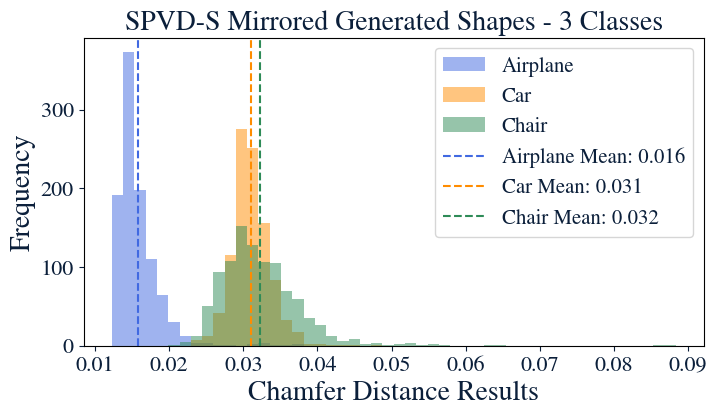

In [61]:
file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_spvd-l_cd_results_airplane.json"
spvd_l_mirrored_airplane_data = load_values_from_json(file_path)  # Limiting to 404 samples
spvd_l_mirrored_airplane_mean = np.mean(spvd_l_mirrored_airplane_data)
print(spvd_l_mirrored_airplane_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_spvd-l_cd_results_car.json"
spvd_l_mirrored_car_data = load_values_from_json(file_path)  # Limiting to 346 samples
spvd_l_mirrored_car_mean = np.mean(spvd_l_mirrored_car_data)
print(spvd_l_mirrored_car_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_spvd-l_cd_results_chair.json"
spvd_l_mirrored_chair_data = load_values_from_json(file_path)  # Limiting to 637 samples
spvd_l_mirrored_chair_mean = np.mean(spvd_l_mirrored_chair_data)
print(spvd_l_mirrored_chair_mean)

data = [spvd_l_mirrored_airplane_data, spvd_l_mirrored_car_data, spvd_l_mirrored_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [spvd_l_mirrored_airplane_mean, spvd_l_mirrored_car_mean, spvd_l_mirrored_chair_mean]
colors = ["royalblue", "darkorange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="SPVD-S Mirrored Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [62]:
print(abs(mirrored_airplane_mean - spvd_l_mirrored_airplane_mean))
print(abs(mirrored_airplane_mean - spvd_l_mirrored_airplane_mean)*100)

0.006395799095490545
0.6395799095490545


In [63]:
print(abs(mirrored_car_mean - spvd_l_mirrored_car_mean))
print(abs(mirrored_car_mean - spvd_l_mirrored_car_mean)*100)

0.011246649815006067
1.1246649815006067


In [64]:
print(abs(mirrored_chair_mean - spvd_l_mirrored_chair_mean))
print(abs(mirrored_chair_mean - spvd_l_mirrored_chair_mean)*100)

0.015131509618992126
1.5131509618992127


## Over Half Objects

### Airplane

In [65]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/_new_exp_over-half_svpd_l_cd_results_airplane.json"
s_spvd_l_airplane_data = load_values_from_json(file_path)
s_spvd_l_airplane_mean = np.mean(s_spvd_l_airplane_data)

data = [s_spvd_l_airplane_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["Airplane"] # , "Car", "Chair"
means = [s_spvd_l_airplane_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Airplane", class_labels=class_labels, means=means, colors=colors)

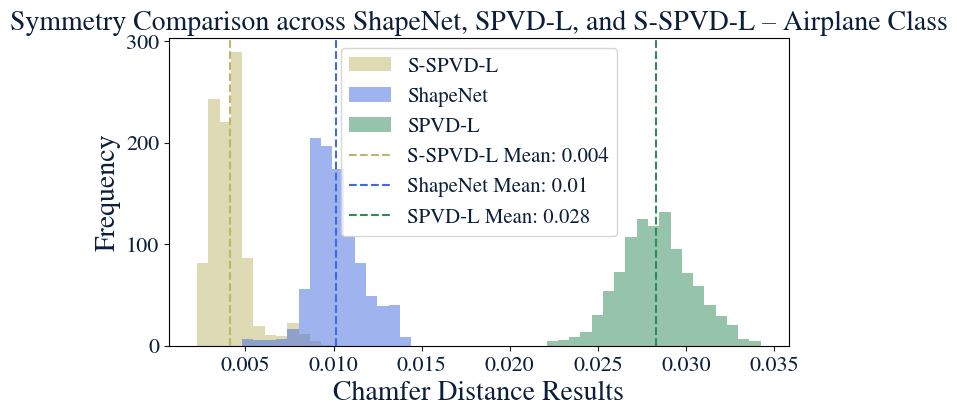

In [66]:
data = [s_spvd_l_airplane_data, shapenet1000_airplane_data, spvd_l_airplane_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-SPVD-L", "ShapeNet", "SPVD-L"] # , "Car", "Chair"
means = [s_spvd_l_airplane_mean, airplane_mean, spvd_l_original_airplane_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, SPVD-L, and S-SPVD-L – Airplane Class", class_labels=class_labels, means=means, colors=colors)

### Car

In [67]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/_new_exp_over-half_svpd_l_cd_results_car.json"
s_spvd_l_car_data = load_values_from_json(file_path)
s_spvd_l_car_mean = np.mean(s_spvd_l_car_data)

data = [s_spvd_l_airplane_data]
class_labels = ["Car"]
means = [s_spvd_l_car_mean]
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Car", class_labels=class_labels, means=means, colors=colors)

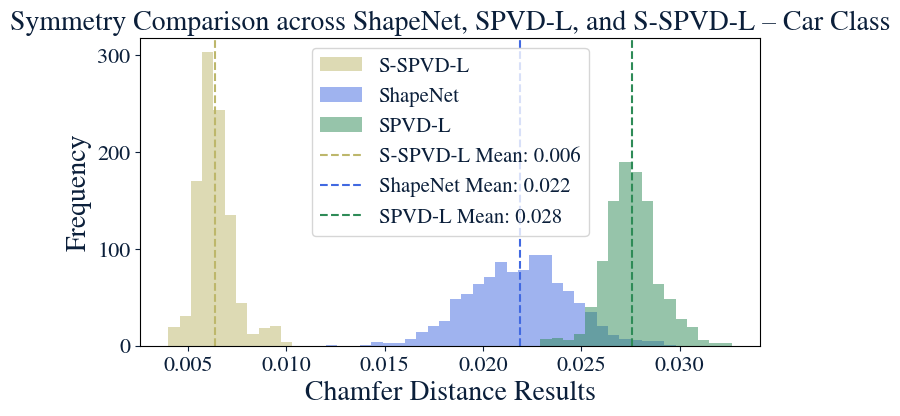

In [68]:
data = [s_spvd_l_car_data, shapenet1000_car_data, spvd_l_car_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-SPVD-L", "ShapeNet", "SPVD-L"] # , "Car", "Chair"
means = [s_spvd_l_car_mean, car_mean, spvd_l_original_car_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, SPVD-L, and S-SPVD-L – Car Class", class_labels=class_labels, means=means, colors=colors)

### Chair

In [69]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/_new_exp_over-half_svpd_l_cd_results_chair.json"
s_spvd_l_chair_data = load_values_from_json(file_path)
s_spvd_l_chair_mean = np.mean(s_spvd_l_chair_data)

data = [s_spvd_l_chair_data]
class_labels = ["Chair"]
means = [s_spvd_l_chair_mean] 
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Chair", class_labels=class_labels, means=means, colors=colors)

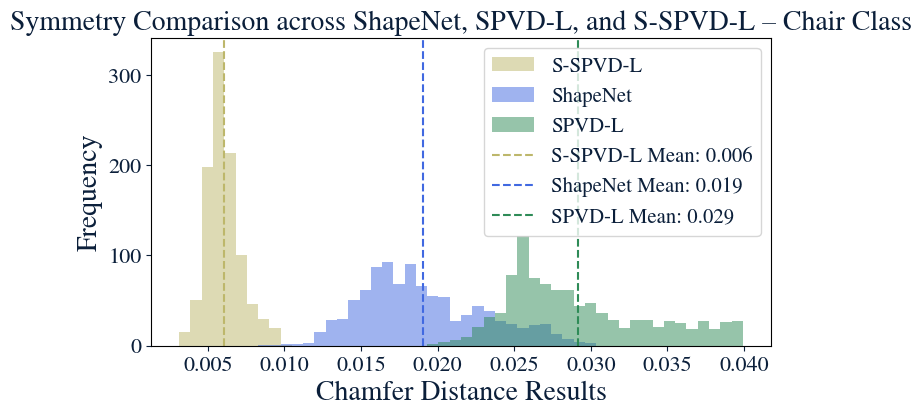

In [70]:
data = [s_spvd_l_chair_data, shapenet1000_chair_data, spvd_l_chair_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-SPVD-L", "ShapeNet", "SPVD-L"] # , "Chair", "Chair"
means = [s_spvd_l_chair_mean, chair_mean, spvd_l_original_chair_mean] # , pvd_Chair_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, SPVD-L, and S-SPVD-L – Chair Class", class_labels=class_labels, means=means, colors=colors)

# DiT-3D

## Original CKPT

0.026244800080449607
0.030143762295450932
0.025875731786038806
1000


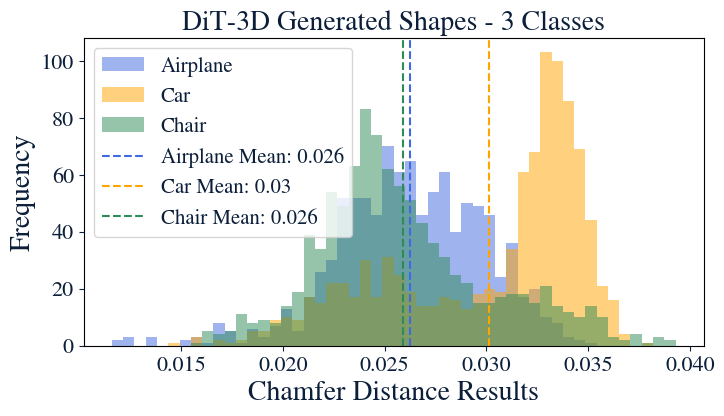

In [71]:
file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_original_dit-3d_cd_results_airplane.json"
dit_3d_airplane_data = load_values_from_json(file_path)  # Limiting to 404 samples
dit_3d_original_airplane_mean = np.mean(dit_3d_airplane_data)
print(dit_3d_original_airplane_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_original_dit-3d_cd_results_car.json"
dit_3d_car_data = load_values_from_json(file_path)  # Limiting to 346 samples
dit_3d_original_car_mean = np.mean(dit_3d_car_data)
print(dit_3d_original_car_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_original_dit-3d_cd_results_chair.json"
dit_3d_chair_data = load_values_from_json(file_path)  # Limiting to 637 samples
dit_3d_original_chair_mean = np.mean(dit_3d_chair_data)
print(dit_3d_original_chair_mean)

print(len(dit_3d_chair_data))

data = [dit_3d_airplane_data, dit_3d_car_data, dit_3d_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [dit_3d_original_airplane_mean, dit_3d_original_car_mean, dit_3d_original_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="DiT-3D Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [72]:
print(abs(airplane_mean - dit_3d_original_airplane_mean))
print(abs(airplane_mean - dit_3d_original_airplane_mean)*100)

0.01611055979913779
1.6110559799137791


In [73]:
print(abs(car_mean - dit_3d_original_car_mean))
print(abs(car_mean - dit_3d_original_car_mean)*100)

0.008279658030294356
0.8279658030294356


In [74]:
print(abs(chair_mean - dit_3d_original_chair_mean))
print(abs(chair_mean - dit_3d_original_chair_mean)*100)

0.006853926538168922
0.6853926538168922


Mirrored Objects

0.024740833651864254
0.021790778381939633
0.017581982411353284


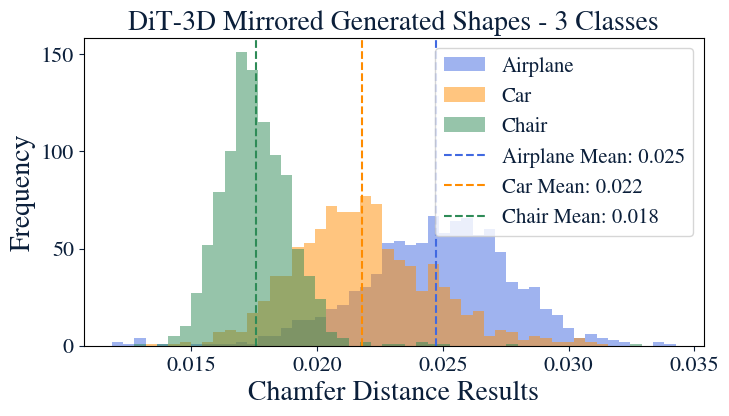

In [75]:
file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_dit-3d_cd_results_airplane.json"
dit_3d_mirrored_airplane_data = load_values_from_json(file_path)  # Limiting to 404 samples
dit_3d_mirrored_airplane_mean = np.mean(dit_3d_mirrored_airplane_data)
print(dit_3d_mirrored_airplane_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_dit-3d_cd_results_car.json"
dit_3d_mirrored_car_data = load_values_from_json(file_path)  # Limiting to 346 samples
dit_3d_mirrored_car_mean = np.mean(dit_3d_mirrored_car_data)
print(dit_3d_mirrored_car_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_dit-3d_cd_results_chair.json"
dit_3d_mirrored_chair_data = load_values_from_json(file_path)  # Limiting to 637 samples
dit_3d_mirrored_chair_mean = np.mean(dit_3d_mirrored_chair_data)
print(dit_3d_mirrored_chair_mean)

data = [dit_3d_mirrored_airplane_data, dit_3d_mirrored_car_data, dit_3d_mirrored_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [dit_3d_mirrored_airplane_mean, dit_3d_mirrored_car_mean, dit_3d_mirrored_chair_mean]
colors = ["royalblue", "darkorange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="DiT-3D Mirrored Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [76]:
print(abs(mirrored_airplane_mean - dit_3d_mirrored_airplane_mean))
print(abs(mirrored_airplane_mean - dit_3d_mirrored_airplane_mean)*100)

0.015372273947984532
1.5372273947984532


In [77]:
print(abs(mirrored_car_mean - dit_3d_mirrored_car_mean))
print(abs(mirrored_car_mean - dit_3d_mirrored_car_mean)*100)

0.002006739352450739
0.20067393524507393


In [78]:
print(abs(mirrored_chair_mean - dit_3d_mirrored_chair_mean))
print(abs(mirrored_chair_mean - dit_3d_mirrored_chair_mean)*100)

0.0004038723791300186
0.04038723791300186


## Over Half Objects

### Airplane

In [79]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/_new_exp_over-half_dit-3d_cd_results_airplane.json"
s_dit_3d_airplane_data = load_values_from_json(file_path)
s_dit_3d_airplane_mean = np.mean(s_dit_3d_airplane_data)

data = [s_dit_3d_airplane_data] # , dit_3d1000_car_data, dit_3d1000_chair_data
class_labels = ["Airplane"] # , "Car", "Chair"
means = [s_dit_3d_airplane_mean] # , dit_3d_car_mean, dit_3d_chair_mean
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="dit_3d Generated Shapes - Airplane", class_labels=class_labels, means=means, colors=colors)

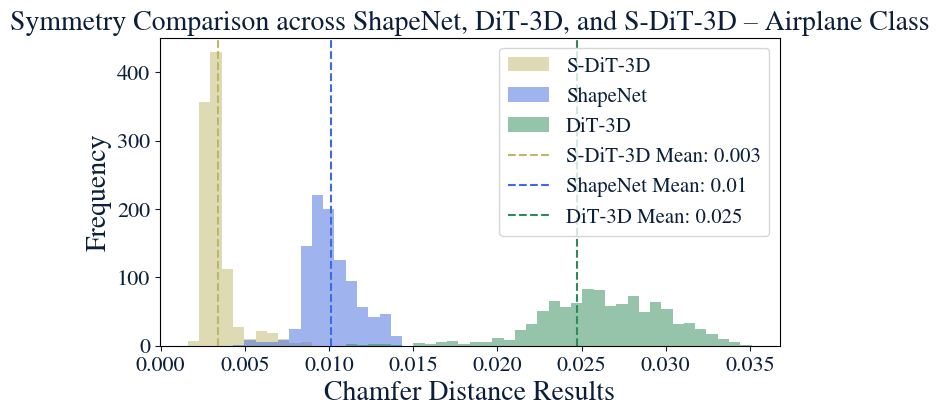

In [80]:
data = [s_dit_3d_airplane_data, shapenet1000_airplane_data, dit_3d_airplane_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-DiT-3D", "ShapeNet", "DiT-3D"] # , "Car", "Chair"
means = [s_dit_3d_airplane_mean, airplane_mean, dit_3d_mirrored_airplane_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, DiT-3D, and S-DiT-3D – Airplane Class", class_labels=class_labels, means=means, colors=colors)

### Car

In [81]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/_new_exp_over-half_dit-3d_cd_results_car.json"
s_dit_3d_car_data = load_values_from_json(file_path)
s_dit_3d_car_mean = np.mean(s_dit_3d_car_data)

data = [s_dit_3d_airplane_data]
class_labels = ["Car"]
means = [s_dit_3d_car_mean]
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Car", class_labels=class_labels, means=means, colors=colors)

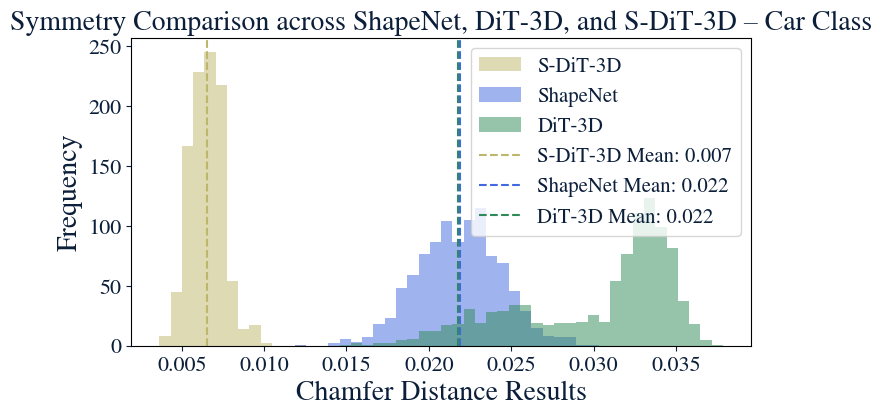

In [82]:
data = [s_dit_3d_car_data, shapenet1000_car_data, dit_3d_car_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-DiT-3D", "ShapeNet", "DiT-3D"] # , "Car", "Chair"
means = [s_dit_3d_car_mean, car_mean, dit_3d_mirrored_car_mean] # , pvd_car_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, DiT-3D, and S-DiT-3D – Car Class", class_labels=class_labels, means=means, colors=colors)

### Chair

In [83]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/_new_exp_over-half_dit-3d_cd_results_chair.json"
s_dit_3d_chair_data = load_values_from_json(file_path)
s_dit_3d_chair_mean = np.mean(s_dit_3d_chair_data)

data = [s_dit_3d_chair_data]
class_labels = ["Chair"]
means = [s_dit_3d_chair_mean] 
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="PVD Generated Shapes - Chair", class_labels=class_labels, means=means, colors=colors)

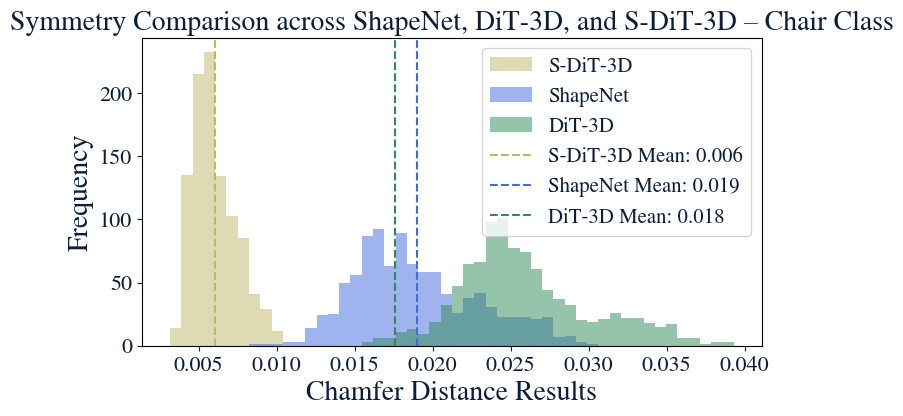

In [84]:
data = [s_dit_3d_chair_data, shapenet1000_chair_data, dit_3d_chair_data] # , pvd1000_car_data, pvd1000_chair_data
class_labels = ["S-DiT-3D", "ShapeNet", "DiT-3D"] # , "Chair", "Chair"
means = [s_dit_3d_chair_mean, chair_mean, dit_3d_mirrored_chair_mean] # , pvd_Chair_mean, pvd_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, DiT-3D, and S-DiT-3D – Chair Class", class_labels=class_labels, means=means, colors=colors)

# LION

## Original CKPT

0.014230586600364834
0.029025735409068262
0.02712174184601458
1000


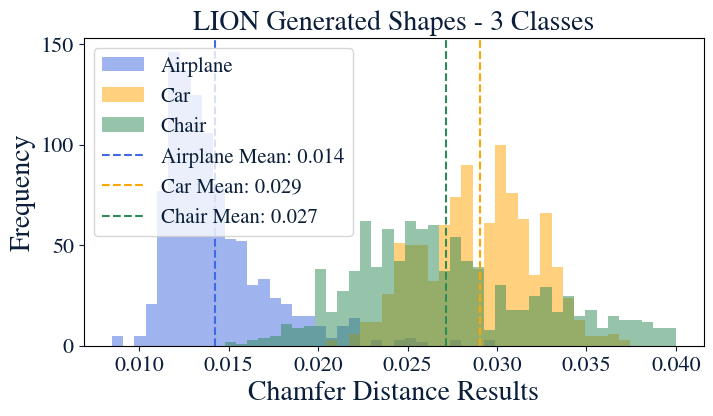

In [85]:
file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/centered_lion_cd_results_airplane.json"
lion250_airplane_data = load_values_from_json(file_path)
lion_airplane_mean = np.mean(lion250_airplane_data)
print(lion_airplane_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/centered_lion_cd_results_car.json"
lion250_car_data = load_values_from_json(file_path)
lion_car_mean = np.mean(lion250_car_data)
print(lion_car_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/centered_lion_cd_results_chair.json"
lion250_chair_data = load_values_from_json(file_path)
lion_chair_mean = np.mean(lion250_chair_data)
print(lion_chair_mean)

print(len(lion250_airplane_data))

data = [lion250_airplane_data, lion250_car_data, lion250_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [lion_airplane_mean, lion_car_mean, lion_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="LION Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [86]:
print(abs(airplane_mean - lion_airplane_mean))
print(abs(airplane_mean - lion_airplane_mean)*100)

0.004096346319053017
0.40963463190530175


In [87]:
print(abs(car_mean - lion_car_mean))
print(abs(car_mean - lion_car_mean)*100)

0.007161631143911686
0.7161631143911686


In [88]:
print(abs(chair_mean - lion_chair_mean))
print(abs(chair_mean - lion_chair_mean)*100)

0.008099936598144696
0.8099936598144696


Mirrored objects

0.01512512761074586
0.02909433954816268
0.026896796240728726
1000


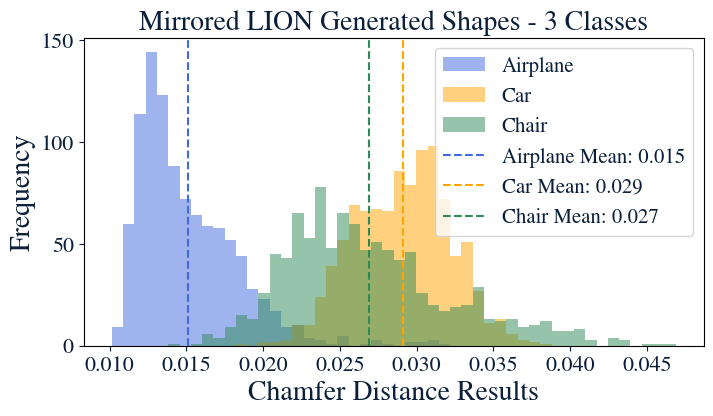

In [89]:
file_path = "/home/ncaytuir/data/Datasets/Scripts/Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_lion_cd_results_airplane.json"
mirrored_lion250_airplane_data = load_values_from_json(file_path)
mirrored_lion_airplane_mean = np.mean(mirrored_lion250_airplane_data)
print(mirrored_lion_airplane_mean)

file_path = "/home/ncaytuir/data/Datasets/Scripts/Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_lion_cd_results_car.json"
mirrored_lion250_car_data = load_values_from_json(file_path)
mirrored_lion_car_mean = np.mean(mirrored_lion250_car_data)
print(mirrored_lion_car_mean)

file_path = "/home/ncaytuir/data/Datasets/Scripts/Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_lion_cd_results_chair.json"
mirrored_lion250_chair_data = load_values_from_json(file_path)
mirrored_lion_chair_mean = np.mean(mirrored_lion250_chair_data)
print(mirrored_lion_chair_mean)

print(len(mirrored_lion250_airplane_data))

data = [mirrored_lion250_airplane_data, mirrored_lion250_car_data, mirrored_lion250_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [mirrored_lion_airplane_mean, mirrored_lion_car_mean, mirrored_lion_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Mirrored LION Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [90]:
print(abs(mirrored_airplane_mean - mirrored_lion_airplane_mean))
print(abs(mirrored_airplane_mean - mirrored_lion_airplane_mean)*100)

0.005756567906866138
0.5756567906866138


In [91]:
print(abs(mirrored_car_mean - mirrored_lion_car_mean))
print(abs(mirrored_car_mean - mirrored_lion_car_mean)*100)

0.009310300518673785
0.9310300518673785


In [92]:
print(abs(mirrored_chair_mean - mirrored_lion_chair_mean))
print(abs(mirrored_chair_mean - mirrored_lion_chair_mean)*100)

0.00971868620850546
0.971868620850546


## Over Half Objects

### Airplane

In [93]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/cd_res_LION_airplane.json"
s_lion_airplane_data = load_values_from_json(file_path)
s_lion_airplane_mean = np.mean(s_lion_airplane_data)

data = [s_lion_airplane_data] # , lion1000_car_data, lion1000_chair_data
class_labels = ["Airplane"] # , "Car", "Chair"
means = [s_lion_airplane_mean] # , lion_car_mean, lion_chair_mean
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="lion Generated Shapes - Airplane", class_labels=class_labels, means=means, colors=colors)

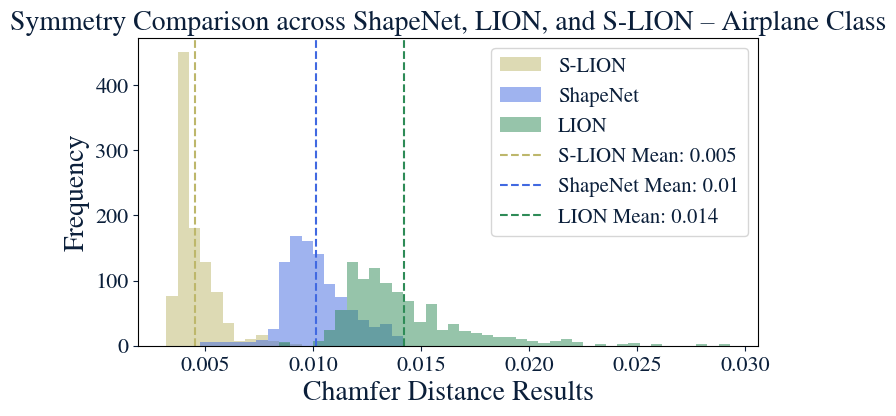

In [94]:
data = [s_lion_airplane_data, shapenet1000_airplane_data, lion250_airplane_data] # , lion1000_car_data, lion1000_chair_data
class_labels = ["S-LION", "ShapeNet", "LION"] # , "Car", "Chair"
means = [s_lion_airplane_mean, airplane_mean, lion_airplane_mean] # , lion_car_mean, lion_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, LION, and S-LION – Airplane Class", class_labels=class_labels, means=means, colors=colors)

### Car

In [95]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/cd_res_LION_car.json"
s_lion_car_data = load_values_from_json(file_path)
s_lion_car_mean = np.mean(s_lion_car_data)

data = [s_lion_airplane_data]
class_labels = ["Car"]
means = [s_lion_car_mean]
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="LION Generated Shapes - Car", class_labels=class_labels, means=means, colors=colors)

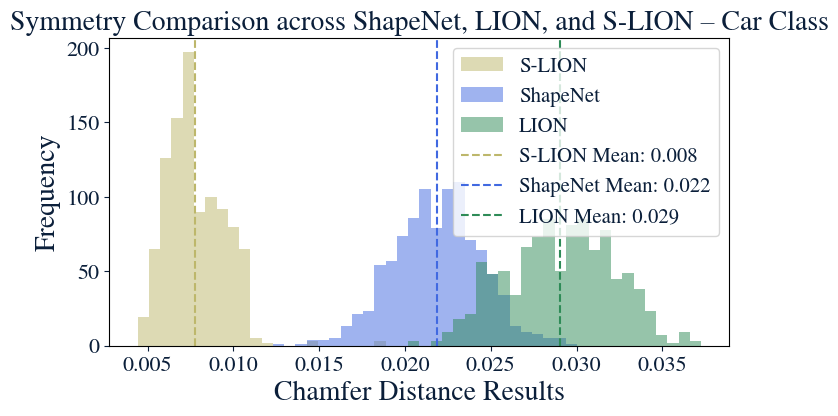

In [96]:
data = [s_lion_car_data, shapenet1000_car_data, lion250_car_data] # , lion1000_car_data, lion1000_chair_data
class_labels = ["S-LION", "ShapeNet", "LION"] # , "Car", "Chair"
means = [s_lion_car_mean, car_mean, lion_car_mean] # , lion_car_mean, lion_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, LION, and S-LION – Car Class", class_labels=class_labels, means=means, colors=colors)

### Chair

In [97]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/cd_res_LION_chair.json"
s_lion_chair_data = load_values_from_json(file_path)
s_lion_chair_mean = np.mean(s_lion_chair_data)

data = [s_lion_chair_data]
class_labels = ["Chair"]
means = [s_lion_chair_mean] 
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="LION Generated Shapes - Chair", class_labels=class_labels, means=means, colors=colors)

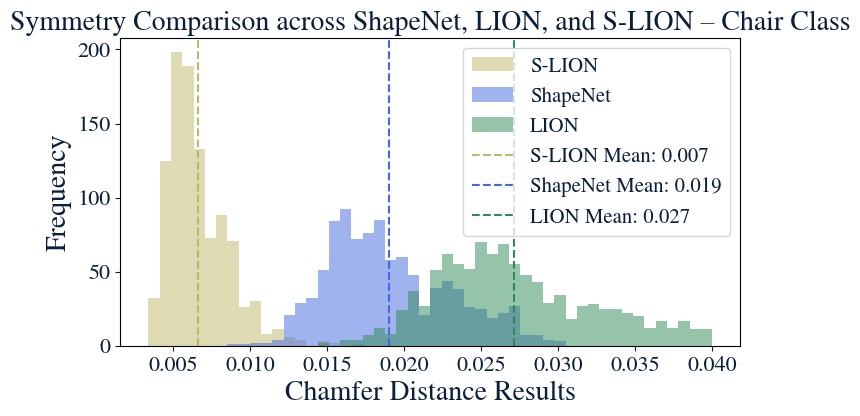

In [98]:
data = [s_lion_chair_data, shapenet1000_chair_data, lion250_chair_data] # , lion1000_car_data, lion1000_chair_data
class_labels = ["S-LION", "ShapeNet", "LION"] # , "Chair", "Chair"
means = [s_lion_chair_mean, chair_mean, lion_chair_mean] # , lion_Chair_mean, lion_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, LION, and S-LION – Chair Class", class_labels=class_labels, means=means, colors=colors)

# XCube

## Original CKPT

0.010576331355888044
0.020928397356044334
0.018951928999945657


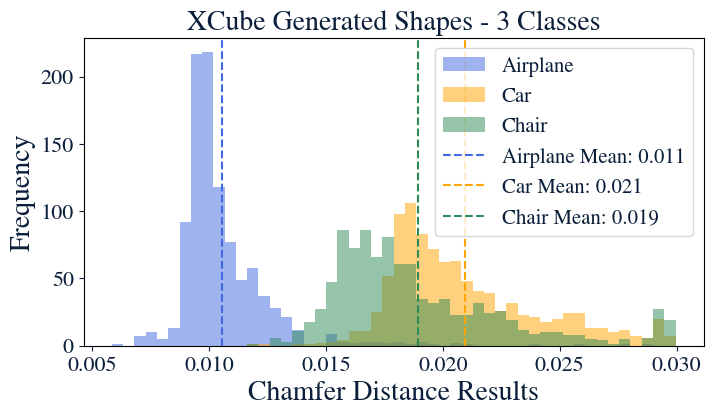

In [99]:
file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/centered_xcube_cd_results_airplane.json"
xcube1000_airplane_data = load_values_from_json(file_path)
xcube_airplane_mean = np.mean(xcube1000_airplane_data)
print(xcube_airplane_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/centered_xcube_cd_results_car.json"
xcube1000_car_data = load_values_from_json(file_path)
xcube_car_mean = np.mean(xcube1000_car_data)
print(xcube_car_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/centered_xcube_cd_results_chair.json"
xcube1000_chair_data = load_values_from_json(file_path)
xcube_chair_mean = np.mean(xcube1000_chair_data)
print(xcube_chair_mean)

data = [xcube1000_airplane_data, xcube1000_car_data, xcube1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [xcube_airplane_mean, xcube_car_mean, xcube_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="XCube Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [100]:
print(abs(airplane_mean - xcube_airplane_mean))
print(abs(airplane_mean - xcube_airplane_mean)*100)

0.0004420910745762275
0.04420910745762275


In [101]:
print(abs(car_mean - xcube_car_mean))
print(abs(car_mean - xcube_car_mean)*100)

0.0009357069091122418
0.09357069091122418


In [102]:
print(abs(chair_mean - xcube_chair_mean))
print(abs(chair_mean - xcube_chair_mean)*100)

6.987624792422625e-05
0.006987624792422625


Mirrored objects

0.015228619316747263
0.02565462279984128
0.02565462279984128


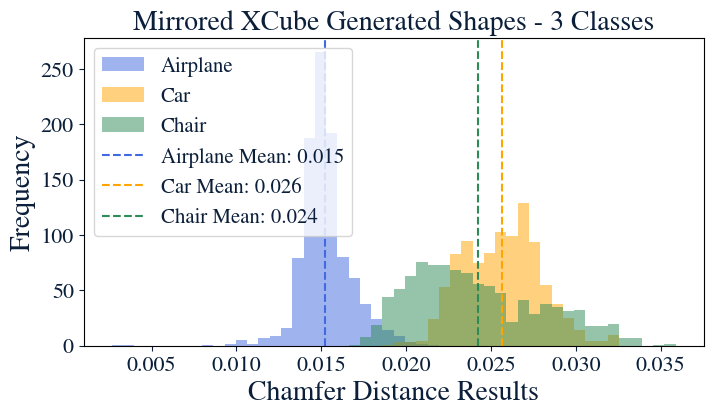

In [103]:
file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_xcube_cd_results_airplane.json"
mirrored_xcube1000_airplane_data = load_values_from_json(file_path)
mirrored_xcube_airplane_mean = np.mean(mirrored_xcube1000_airplane_data)
print(mirrored_xcube_airplane_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_xcube_cd_results_car.json"
mirrored_xcube1000_car_data = load_values_from_json(file_path)
mirrored_xcube_car_mean = np.mean(mirrored_xcube1000_car_data)
print(mirrored_xcube_car_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_xcube_cd_results_chair.json"
mirrored_xcube1000_chair_data = load_values_from_json(file_path)
mirrored_xcube_chair_mean = np.mean(mirrored_xcube1000_chair_data)
print(mirrored_xcube_car_mean)

data = [mirrored_xcube1000_airplane_data, mirrored_xcube1000_car_data, mirrored_xcube1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [mirrored_xcube_airplane_mean, mirrored_xcube_car_mean, mirrored_xcube_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Mirrored XCube Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [104]:
print(abs(mirrored_airplane_mean - mirrored_xcube_airplane_mean))
print(abs(mirrored_airplane_mean - mirrored_xcube_airplane_mean)*100)

0.0058600596128675405
0.5860059612867541


In [105]:
print(abs(mirrored_car_mean - mirrored_xcube_car_mean))
print(abs(mirrored_car_mean - mirrored_xcube_car_mean)*100)

0.005870583770352385
0.5870583770352384


In [106]:
print(abs(mirrored_chair_mean - mirrored_xcube_chair_mean))
print(abs(mirrored_chair_mean - mirrored_xcube_chair_mean)*100)

0.00704136937551882
0.704136937551882


## Over Half Objects

### Airplane

In [107]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/cd_res_XCube_airplane.json"
s_xcube_airplane_data = load_values_from_json(file_path)
s_xcube_airplane_mean = np.mean(s_xcube_airplane_data)

data = [s_xcube_airplane_data] # , xcube1000_car_data, xcube1000_chair_data
class_labels = ["Airplane"] # , "Car", "Chair"
means = [s_xcube_airplane_mean] # , xcube_car_mean, xcube_chair_mean
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="XCube Generated Shapes - Airplane", class_labels=class_labels, means=means, colors=colors)

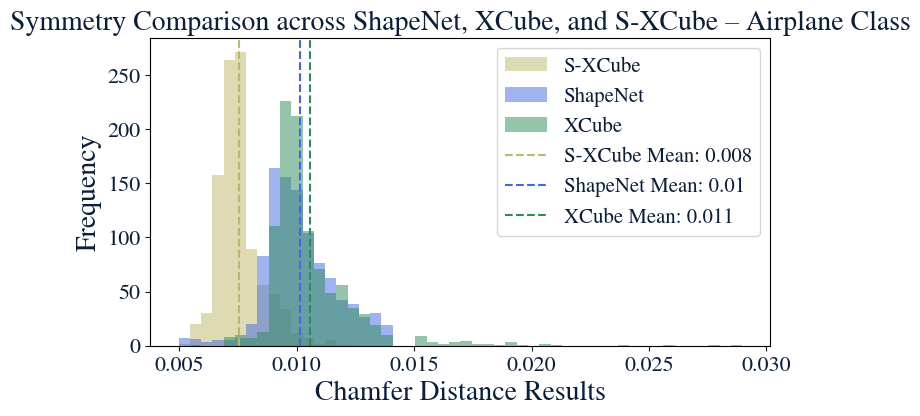

In [108]:
data = [s_xcube_airplane_data, shapenet1000_airplane_data, xcube1000_airplane_data] # , xcube1000_car_data, xcube1000_chair_data
class_labels = ["S-XCube", "ShapeNet", "XCube"] # , "Car", "Chair"
means = [s_xcube_airplane_mean, airplane_mean, xcube_airplane_mean] # , xcube_car_mean, xcube_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, XCube, and S-XCube – Airplane Class", class_labels=class_labels, means=means, colors=colors)

### Car

In [109]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/cd_res_XCube_car.json"
s_xcube_car_data = load_values_from_json(file_path)
s_xcube_car_mean = np.mean(s_xcube_car_data)

data = [s_xcube_airplane_data]
class_labels = ["Car"]
means = [s_xcube_car_mean]
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="XCube Generated Shapes - Car", class_labels=class_labels, means=means, colors=colors)

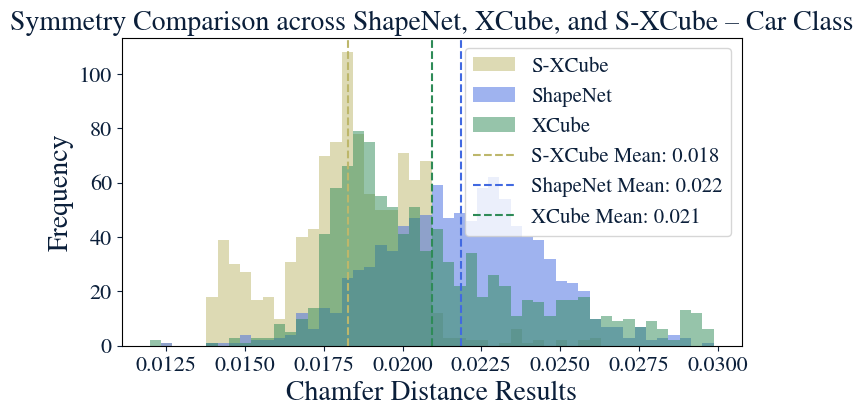

In [110]:
data = [s_xcube_car_data, shapenet1000_car_data, xcube1000_car_data] # , xcube1000_car_data, xcube1000_chair_data
class_labels = ["S-XCube", "ShapeNet", "XCube"] # , "Car", "Chair"
means = [s_xcube_car_mean, car_mean, xcube_car_mean] # , xcube_car_mean, xcube_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, XCube, and S-XCube – Car Class", class_labels=class_labels, means=means, colors=colors)

### Chair

In [111]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/cd_res_XCube_chair.json"
s_xcube_chair_data = load_values_from_json(file_path)
s_xcube_chair_mean = np.mean(s_xcube_chair_data)

data = [s_xcube_chair_data]
class_labels = ["Chair"]
means = [s_xcube_chair_mean] 
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="XCube Generated Shapes - Chair", class_labels=class_labels, means=means, colors=colors)

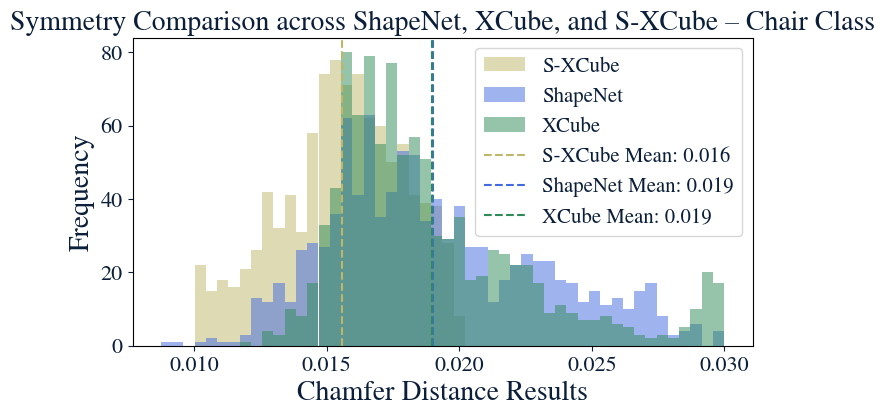

In [112]:
data = [s_xcube_chair_data, shapenet1000_chair_data, xcube1000_chair_data] # , xcube1000_car_data, xcube1000_chair_data
class_labels = ["S-XCube", "ShapeNet", "XCube"] # , "Chair", "Chair"
means = [s_xcube_chair_mean, chair_mean, xcube_chair_mean] # , xcube_Chair_mean, xcube_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, XCube, and S-XCube – Chair Class", class_labels=class_labels, means=means, colors=colors)

# SLIDE 3D

## Original CKPT

0.012253659075882679
0.02106521697697054
0.021119624999406287


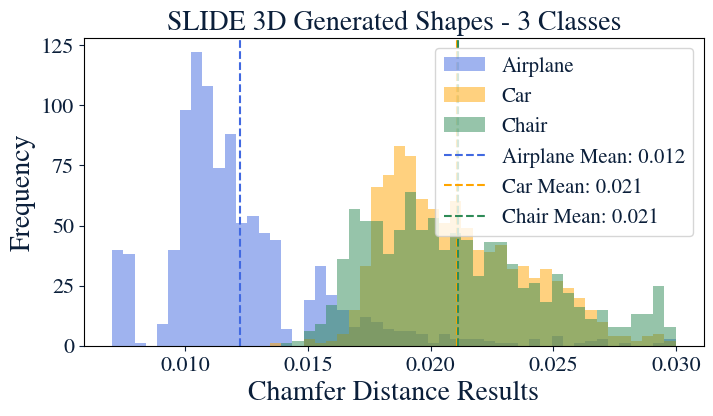

In [113]:
file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/centered_slide3d_cd_results_airplane.json"
slide1000_airplane_data = load_values_from_json(file_path)
slide_airplane_mean = np.mean(slide1000_airplane_data)
print(slide_airplane_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/centered_slide3d_cd_results_car.json"
slide1000_car_data = load_values_from_json(file_path)
slide_car_mean = np.mean(slide1000_car_data)
print(slide_car_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/centered_slide3d_cd_results_chair.json"
slide1000_chair_data = load_values_from_json(file_path)
slide_chair_mean = np.mean(slide1000_chair_data)
print(slide_chair_mean)

data = [slide1000_airplane_data, slide1000_car_data, slide1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [slide_airplane_mean, slide_car_mean, slide_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="SLIDE 3D Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [114]:
print(abs(airplane_mean - slide_airplane_mean))
print(abs(airplane_mean - slide_airplane_mean)*100)

0.002119418794570862
0.2119418794570862


In [115]:
print(abs(car_mean - slide_car_mean))
print(abs(car_mean - slide_car_mean)*100)

0.0007988872881860357
0.07988872881860357


In [116]:
print(abs(chair_mean - slide_chair_mean))
print(abs(chair_mean - slide_chair_mean)*100)

0.0020978197515364033
0.20978197515364033


Mirrored dataset

0.11897023470497306
0.049535418940466085
0.06243965339875978


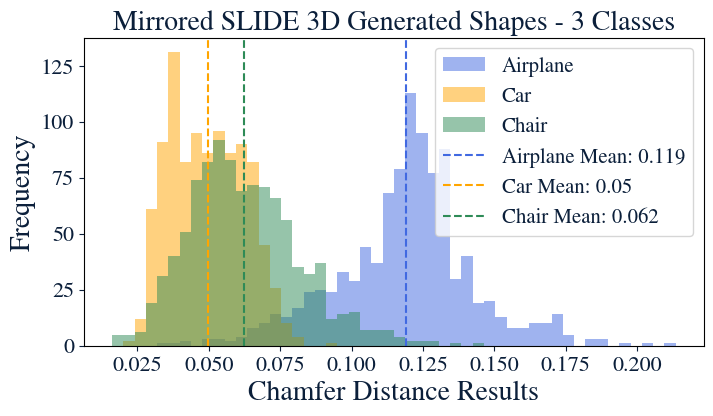

In [117]:
file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_slide3d_cd_results_airplane.json"
mirrored_slide1000_airplane_data = load_values_from_json(file_path)
mirrored_slide_airplane_mean = np.mean(mirrored_slide1000_airplane_data)
print(mirrored_slide_airplane_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_slide3d_cd_results_car.json"
mirrored_slide1000_car_data = load_values_from_json(file_path)
mirrored_slide_car_mean = np.mean(mirrored_slide1000_car_data)
print(mirrored_slide_car_mean)

file_path = "Symmetry_Computation/Results_CD_NewDataset_NormalizedPC/_new_exp_mirrored_slide3d_cd_results_chair.json"
mirrored_slide1000_chair_data = load_values_from_json(file_path)
mirrored_slide_chair_mean = np.mean(mirrored_slide1000_chair_data)
print(mirrored_slide_chair_mean)

data = [mirrored_slide1000_airplane_data, mirrored_slide1000_car_data, mirrored_slide1000_chair_data]
class_labels = ["Airplane", "Car", "Chair"]
means = [mirrored_slide_airplane_mean, mirrored_slide_car_mean, mirrored_slide_chair_mean]
colors = ["royalblue", "orange", "seagreen"] # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Mirrored SLIDE 3D Generated Shapes - 3 Classes", class_labels=class_labels, means=means, colors=colors)

In [118]:
print(abs(mirrored_airplane_mean - mirrored_slide_airplane_mean))
print(abs(mirrored_airplane_mean - mirrored_slide_airplane_mean)*100)

0.10960167500109334
10.960167500109334


In [119]:
print(abs(mirrored_car_mean - mirrored_slide_car_mean))
print(abs(mirrored_car_mean - mirrored_slide_car_mean)*100)

0.02975137991097719
2.975137991097719


In [120]:
print(abs(mirrored_chair_mean - mirrored_slide_chair_mean))
print(abs(mirrored_chair_mean - mirrored_slide_chair_mean)*100)

0.04526154336653651
4.526154336653651


## Over Half Objects

### Airplane

In [121]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/cd_res_SLIDE3D_airplane.json"
s_slide_airplane_data = load_values_from_json(file_path)
s_slide_airplane_mean = np.mean(s_slide_airplane_data)

data = [s_slide_airplane_data] # , slide1000_car_data, slide1000_chair_data
class_labels = ["Airplane"] # , "Car", "Chair"
means = [s_slide_airplane_mean] # , slide_car_mean, slide_chair_mean
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="SLIDE 3D Generated Shapes - Airplane", class_labels=class_labels, means=means, colors=colors)

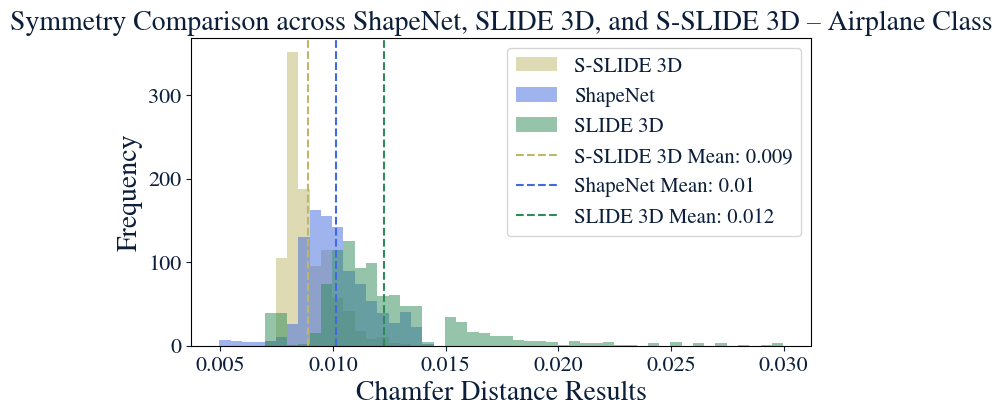

In [122]:
data = [s_slide_airplane_data, shapenet1000_airplane_data, slide1000_airplane_data] # , slide1000_car_data, slide1000_chair_data
class_labels = ["S-SLIDE 3D", "ShapeNet", "SLIDE 3D"] # , "Car", "Chair"
means = [s_slide_airplane_mean, airplane_mean, slide_airplane_mean] # , slide_car_mean, slide_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, SLIDE 3D, and S-SLIDE 3D – Airplane Class", class_labels=class_labels, means=means, colors=colors)

### Car

In [123]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/cd_res_SLIDE3D_car.json"
s_slide_car_data = load_values_from_json(file_path)
s_slide_car_mean = np.mean(s_slide_car_data)

data = [s_slide_airplane_data]
class_labels = ["Car"]
means = [s_slide_car_mean]
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="SLIDE 3D Generated Shapes - Car", class_labels=class_labels, means=means, colors=colors)

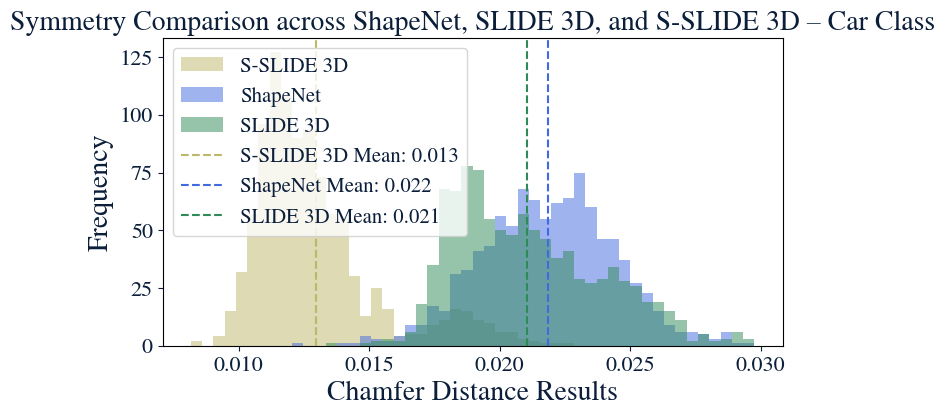

In [124]:
data = [s_slide_car_data, shapenet1000_car_data, slide1000_car_data] # , slide1000_car_data, slide1000_chair_data
class_labels = ["S-SLIDE 3D", "ShapeNet", "SLIDE 3D"] # , "Car", "Chair"
means = [s_slide_car_mean, car_mean, slide_car_mean] # , slide_car_mean, slide_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, SLIDE 3D, and S-SLIDE 3D – Car Class", class_labels=class_labels, means=means, colors=colors)

### Chair

In [125]:
file_path = "Symmetry_Computation/Results_CD_Over_Half_NormalizedPC/cd_res_SLIDE3D_chair.json"
s_slide_chair_data = load_values_from_json(file_path)
s_slide_chair_mean = np.mean(s_slide_chair_data)

data = [s_slide_chair_data]
class_labels = ["Chair"]
means = [s_slide_chair_mean] 
colors = ["royalblue"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

#generate_histogram(data=data, bins=30, alpha=0.5, title="slSLIDE 3Dide Generated Shapes - Chair", class_labels=class_labels, means=means, colors=colors)

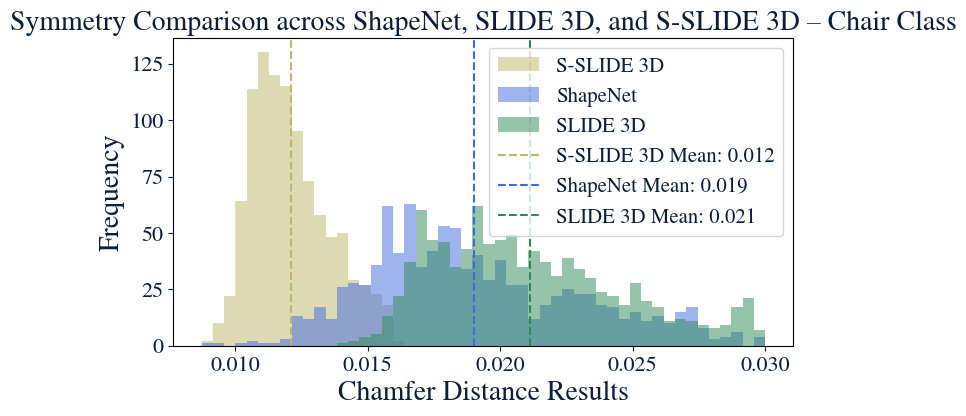

In [126]:
data = [s_slide_chair_data, shapenet1000_chair_data, slide1000_chair_data] # , slide1000_car_data, slide1000_chair_data
class_labels = ["S-SLIDE 3D", "ShapeNet", "SLIDE 3D"] # , "Chair", "Chair"
means = [s_slide_chair_mean, chair_mean, slide_chair_mean] # , slide_Chair_mean, slide_chair_mean
colors = ["darkkhaki", "royalblue", "seagreen"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram(data=data, bins=30, alpha=0.5, title="Symmetry Comparison across ShapeNet, SLIDE 3D, and S-SLIDE 3D – Chair Class", class_labels=class_labels, means=means, colors=colors)

# Joint histograms

## Airplane

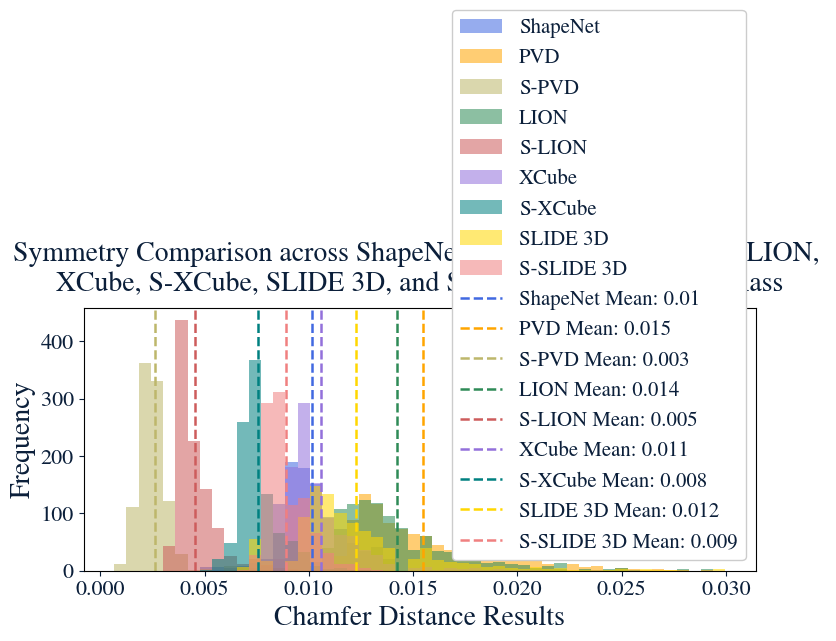

✅ Histograma guardado en: s-airplane.pdf


In [127]:
data = [shapenet1000_airplane_data, pvd1000_airplane_data, s_pvd_airplane_data, lion250_airplane_data, s_lion_airplane_data, xcube1000_airplane_data, s_xcube_airplane_data, slide1000_airplane_data, s_slide_airplane_data] # , lion1000_car_data, lion1000_chair_data
class_labels = ["ShapeNet", "PVD", "S-PVD", "LION", "S-LION", "XCube", "S-XCube", "SLIDE 3D", "S-SLIDE 3D"] # , "Car", "Chair"
means = [airplane_mean, pvd_original_airplane_mean, s_pvd_airplane_mean, lion_airplane_mean, s_lion_airplane_mean, xcube_airplane_mean, s_xcube_airplane_mean, slide_airplane_mean, s_slide_airplane_mean] # , lion_car_mean, lion_chair_mean
colors = ["royalblue", "orange", "darkkhaki", "seagreen", "indianred", "mediumpurple", "teal", "gold", "lightcoral"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram_and_save(data=data, g_class='airplane', bins=30, alpha=0.55, title="Symmetry Comparison across ShapeNet, PVD, S-PVD, LION, S-LION, \nXCube, S-XCube, SLIDE 3D, and S-SLIDE 3D – Airplane Class", class_labels=class_labels, means=means, colors=colors, output_path="s-airplane.pdf")

## Car

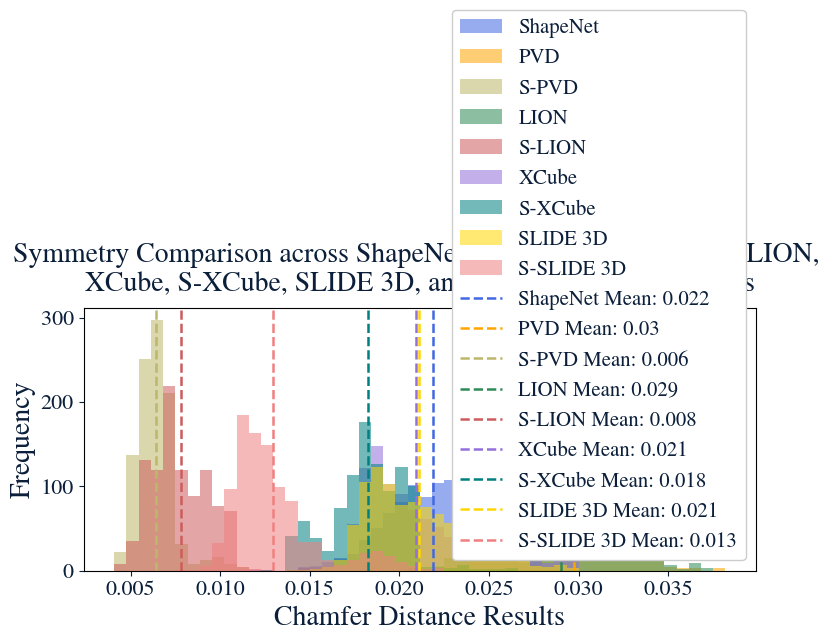

✅ Histograma guardado en: s-car.pdf


In [128]:
data = [shapenet1000_car_data, pvd1000_car_data, s_pvd_car_data, lion250_car_data, s_lion_car_data, xcube1000_car_data, s_xcube_car_data, slide1000_car_data, s_slide_car_data] # , lion1000_car_data, lion1000_chair_data
class_labels = ["ShapeNet", "PVD", "S-PVD", "LION", "S-LION", "XCube", "S-XCube", "SLIDE 3D", "S-SLIDE 3D"] # , "Car", "Chair"
means = [car_mean, pvd_original_car_mean, s_pvd_car_mean, lion_car_mean, s_lion_car_mean, xcube_car_mean, s_xcube_car_mean, slide_car_mean, s_slide_car_mean] # , lion_car_mean, lion_chair_mean
colors = ["royalblue", "orange", "darkkhaki", "seagreen", "indianred", "mediumpurple", "teal", "gold", "lightcoral"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram_and_save(data=data, g_class='car', bins=30, alpha=0.55, title="Symmetry Comparison across ShapeNet, PVD, S-PVD, LION, S-LION, \nXCube, S-XCube, SLIDE 3D, and S-SLIDE 3D – Car Class", class_labels=class_labels, means=means, colors=colors, output_path="s-car.pdf")

## Chair

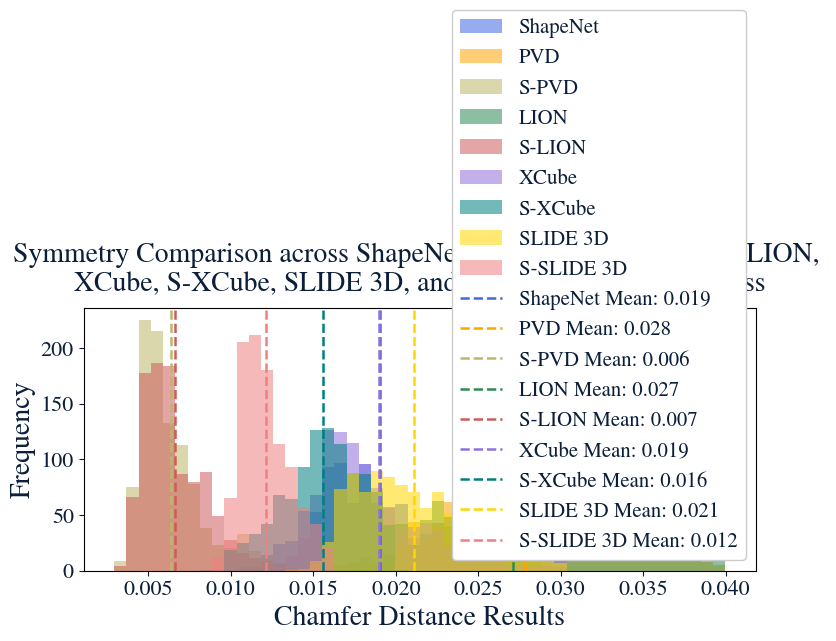

✅ Histograma guardado en: s-chair.pdf


In [129]:
data = [shapenet1000_chair_data, pvd1000_chair_data, s_pvd_chair_data, lion250_chair_data, s_lion_chair_data, xcube1000_chair_data, s_xcube_chair_data, slide1000_chair_data, s_slide_chair_data] # , lion1000_chair_data, lion1000_chair_data
class_labels = ["ShapeNet", "PVD", "S-PVD", "LION", "S-LION", "XCube", "S-XCube", "SLIDE 3D", "S-SLIDE 3D"] # , "chair", "Chair"
means = [chair_mean, pvd_original_chair_mean, s_pvd_chair_mean, lion_chair_mean, s_lion_chair_mean, xcube_chair_mean, s_xcube_chair_mean, slide_chair_mean, s_slide_chair_mean] # , lion_chair_mean, lion_chair_mean
colors = ["royalblue", "orange", "darkkhaki", "seagreen", "indianred", "mediumpurple", "teal", "gold", "lightcoral"] #, "orange", "seagreen" # royalblue, darkorange, seagreen, indianred, mediumpurple, gold, teal, slateblue, lightcoral, darkkhaki

generate_histogram_and_save(data=data, g_class='chair', bins=30, alpha=0.55, title="Symmetry Comparison across ShapeNet, PVD, S-PVD, LION, S-LION, \nXCube, S-XCube, SLIDE 3D, and S-SLIDE 3D – Chair Class", class_labels=class_labels, means=means, colors=colors, output_path="s-chair.pdf")

# Heatmaps

## Only original models

## Airplane

✅ Saved figure: symmetry_airplane.pdf


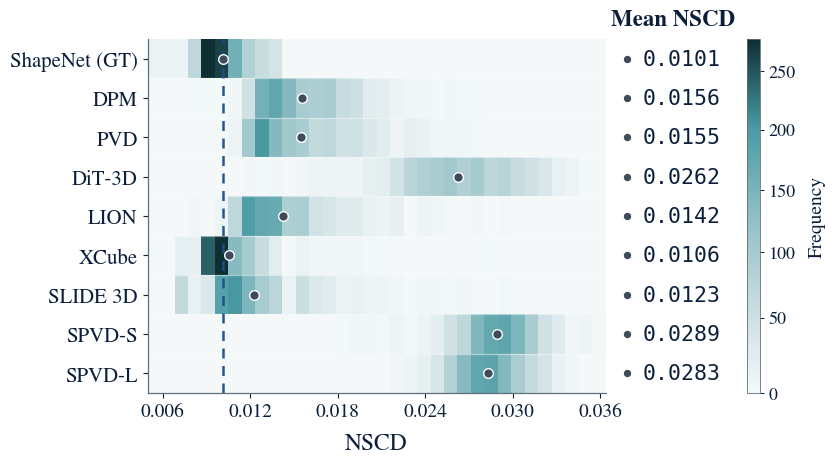

(array([[ 11,   9,  10,  70, 293, 264, 159,  85,  57,  42,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   1,   1,   1,   3,  49, 157, 178, 140,  97,  92,
          97,  60,  53,  24,  19,   9,   5,   5,   1,   3,   1,   1,   0,
           1,   0,   0,   0,   1,   0,   0,   1],
        [  0,   0,   0,   0,   0,   1,   6, 105, 204, 140, 107,  96,  64,
          70,  49,  51,  32,  24,   7,  16,  12,   5,   4,   5,   2,   0,
           0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   3,   2,   3,   0,   5,   6,
           8,   7,   8,  16,  22,  44,  77,  90,  96, 106,  88, 100,  73,
          80,  60,  49,  34,  15,   7,   1,   0],
        [  0,   0,   0,   5,   0,   8,  70, 195, 174, 170,  91,  95,  46,
          39,  26,  25,  12,   9,  17,   0,   6,   4,   2,   0,   3,   0,
           3,   0,   0,   0,   0,   0,   0,   0],
        [ 

In [130]:
results = {
    "ShapeNet (GT)": shapenet1000_airplane_data,
    "DPM": dpm_airplane_data,
    "PVD": pvd1000_airplane_data,
    "DiT-3D": dit_3d_airplane_data,
    "LION": lion250_airplane_data,
    "XCube": xcube1000_airplane_data,
    "SLIDE 3D": slide1000_airplane_data,
    "SPVD-S": spvd_s_airplane_data,
    "SPVD-L": spvd_l_airplane_data
}

models = list(results.keys())
title = "Symmetry Evaluation Across 3D Generative Models - Airplane Class"
output_path = "symmetry_airplane.pdf"

generate_heatmap_and_save(results, models, title, output_path)

## Car

✅ Saved figure: symmetry_car.pdf


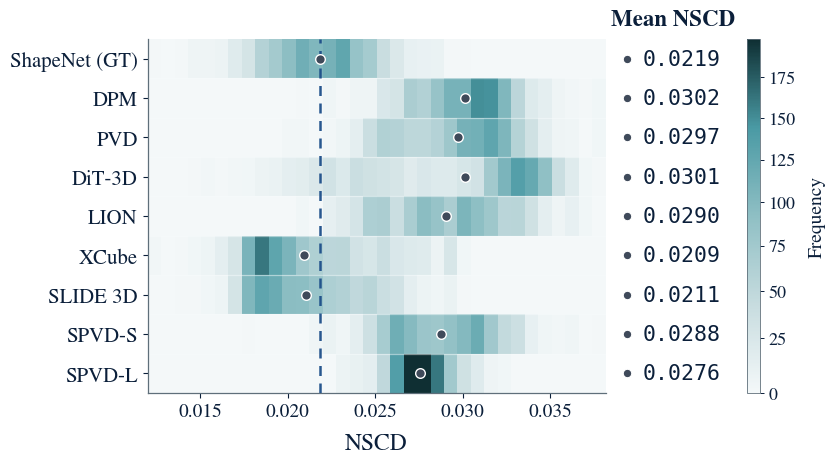

(array([[  1,   0,   1,   5,   5,   7,  19,  30,  59,  73,  93, 115, 103,
         111, 127,  85,  72,  41,  23,  11,   9,   8,   1,   1,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
           4,   1,   5,   5,  24,  30,  67,  61,  84, 110, 110, 150, 148,
         103,  52,  21,  13,   5,   2,   1,   3],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   2,   2,   0,
           2,   6,  14,  40,  62,  59,  51,  51,  59,  78, 111, 113, 128,
         104,  58,  35,  13,   5,   4,   0,   3],
        [  0,   0,   0,   1,   2,   1,   2,   3,   7,   8,  14,  16,  23,
          32,  22,  39,  35,  31,  28,  18,  24,  21,  21,  27,  32,  75,
         107, 136, 122,  91,  39,  19,   3,   1],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,   0,
          12,  18,  29,  65,  67,  40,  68,  95,  84,  67, 106,  92,  78,
          54,  55,  35,  13,   5,  11,   3,   0],
        [ 

In [131]:
results = {
    "ShapeNet (GT)": shapenet1000_car_data,
    "DPM": dpm_car_data,
    "PVD": pvd1000_car_data,
    "DiT-3D": dit_3d_car_data,
    "LION": lion250_car_data,
    "XCube": xcube1000_car_data,
    "SLIDE 3D": slide1000_car_data,
    "SPVD-S": spvd_s_car_data,
    "SPVD-L": spvd_l_car_data
}

models = list(results.keys())
title = "Symmetry Evaluation Across 3D Generative Models - Car Class"
output_path = "symmetry_car.pdf"

generate_heatmap_and_save(results, models, title, output_path)

## Chair

✅ Saved figure: symmetry_chair.pdf


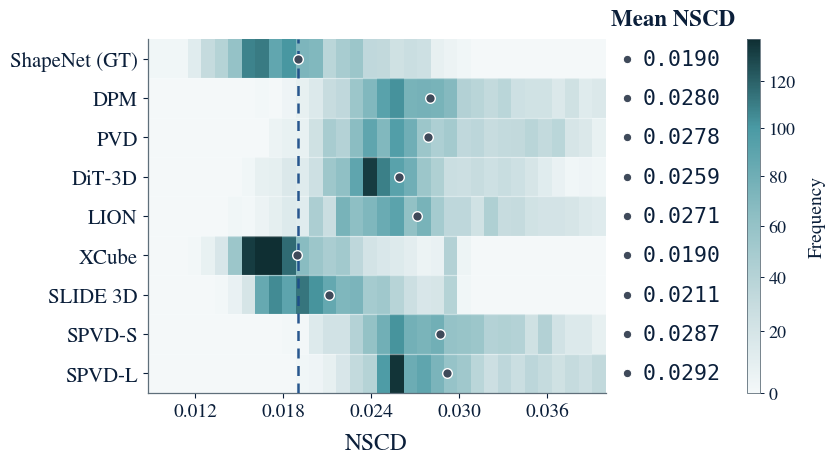

(array([[  2,   2,   2,  12,  31,  40,  60, 108, 111,  88, 101,  73,  71,
          37,  48,  56,  34,  33,  24,  27,  25,   8,   5,   2,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   3,   8,  15,
          30,  34,  56,  71,  92, 103,  76,  77,  76,  69,  42,  38,  32,
          37,  25,  23,  23,  16,  24,  13,  16],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   5,   7,   7,  24,
          48,  41,  66,  89,  71,  96,  80,  56,  45,  51,  34,  36,  30,
          32,  33,  38,  32,  37,  19,  16,   7],
        [  0,   0,   0,   0,   0,   0,   0,   2,   8,   9,  16,  13,  25,
          54,  63,  89, 133, 109,  92,  80,  56,  44,  28,  26,  30,  25,
          29,  25,  19,  12,   6,   2,   3,   2],
        [  0,   0,   0,   0,   0,   0,   2,   1,   5,   9,  14,  12,  46,
          27,  76,  64,  72,  83,  91,  62,  76,  50,  35,  35,  23,  44,
          30,  31,  23,  21,  21,  19,  15,  13],
        [ 

In [132]:
results = {
    "ShapeNet (GT)": shapenet1000_chair_data,
    "DPM": dpm_chair_data,
    "PVD": pvd1000_chair_data,
    "DiT-3D": dit_3d_chair_data,
    "LION": lion250_chair_data,
    "XCube": xcube1000_chair_data,
    "SLIDE 3D": slide1000_chair_data,
    "SPVD-S": spvd_s_chair_data,
    "SPVD-L": spvd_l_chair_data
}

models = list(results.keys())
title = "Symmetry Evaluation Across 3D Generative Models - Chair Class"
output_path = "symmetry_chair.pdf"

generate_heatmap_and_save(results, models, title, output_path)

## Original plus S-variants models

### Airplane

✅ Saved figure: s-symmetry_airplane.pdf


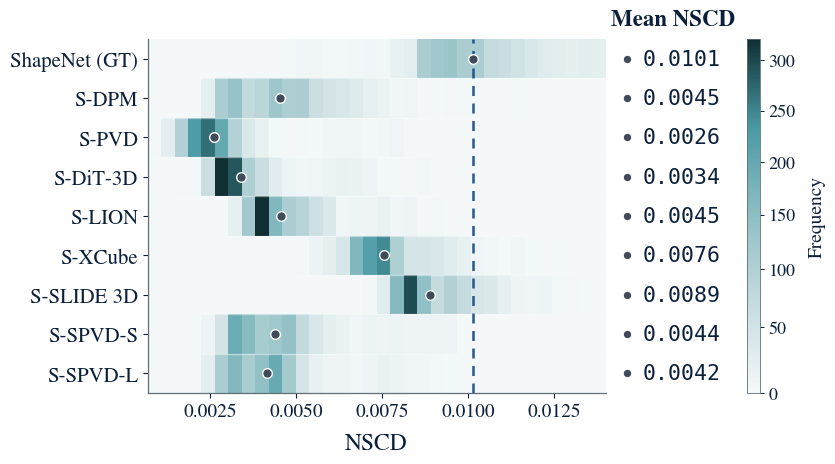

(array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   5,   5,
           3,   3,   4,   5,   4,  16,  23, 108, 124, 133, 109, 110,  71,
          63,  53,  40,  29,  25,  21,  25,  20],
        [  0,   0,   0,   0,  21, 109, 136,  76,  86, 127, 105, 106,  62,
          48,  40,  31,  19,  13,   5,   6,   2,   1,   2,   3,   1,   0,
           0,   1,   0,   0,   0,   0,   0,   0],
        [  2,  23,  98, 228, 268, 200,  95,  37,  16,   1,   0,   3,   1,
           5,   5,   5,   1,   4,   6,   2,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   2,   3,  63, 371, 288, 104,  64,  28,   9,   5,   6,
          10,  15,  13,   7,   3,   3,   2,   4,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,  18, 120, 350, 165, 107,  93,  58,
          35,   5,   9,   8,  15,   5,   7,   2,   3,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0],
        [ 

In [133]:
results = {
    "ShapeNet (GT)": shapenet1000_airplane_data,
    #"DPM": dpm_airplane_data,
    "S-DPM": s_dpm_airplane_data,
    #"PVD": pvd1000_airplane_data,
    "S-PVD": s_pvd_airplane_data,
    #"DiT-3D": dit_3d_airplane_data,
    "S-DiT-3D": s_dit_3d_airplane_data,
    #"LION": lion250_airplane_data,
    "S-LION": s_lion_airplane_data,
    #"XCube": xcube1000_airplane_data,
    "S-XCube": s_xcube_airplane_data,
    #"SLIDE 3D": slide1000_airplane_data,
    "S-SLIDE 3D": s_slide_airplane_data,
    #"SPVD-S": spvd_s_airplane_data,
    "S-SPVD-S": s_spvd_s_airplane_data,
    #"SPVD-L": spvd_l_airplane_data,
    "S-SPVD-L": s_spvd_l_airplane_data
}

models = list(results.keys())
title = "Symmetry Evaluation Across 3D Generative Models - Airplane Class"
output_path = "s-symmetry_airplane.pdf"

generate_heatmap_and_save(results, models, title, output_path)

### Car

✅ Saved figure: s-symmetry_car.pdf


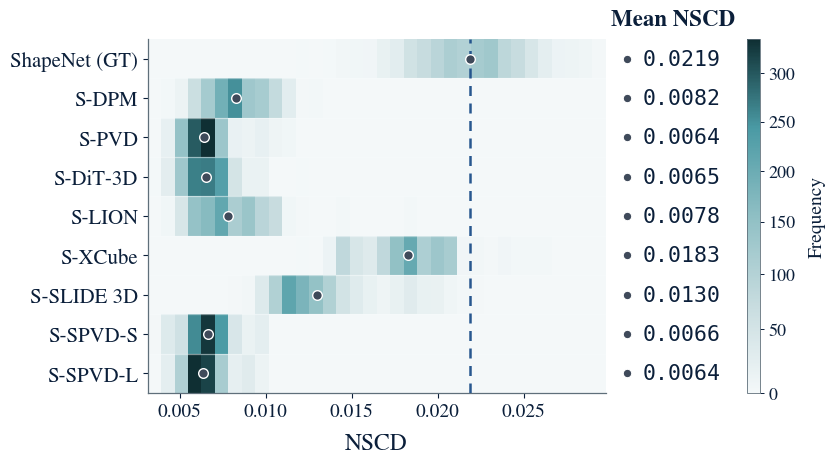

(array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
           1,   4,   5,   6,  17,  26,  56,  73,  91, 112, 103, 120, 129,
          86,  73,  44,  23,  11,  10,   7,   2],
        [  0,   3,  12,  65, 122, 191, 251, 130, 119,  76,  26,   2,   3,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0],
        [  0,  18, 147, 297, 345, 134,  15,  12,  18,   9,   5,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0],
        [  1,  25, 131, 265, 269, 230,  50,  14,  14,   0,   0,   1,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   5,  44, 146, 165, 212, 113, 139,  92,  71,   5,   2,   0,
           0,   3,   0,   0,   0,   0,   3,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0],
        [ 

In [134]:
results = {
    "ShapeNet (GT)": shapenet1000_car_data,
    #"DPM": dpm_car_data,
    "S-DPM": s_dpm_car_data,
    #"PVD": pvd1000_car_data,
    "S-PVD": s_pvd_car_data,
    #"DiT-3D": dit_3d_car_data,
    "S-DiT-3D": s_dit_3d_car_data,
    #"LION": lion250_car_data,
    "S-LION": s_lion_car_data,
    #"XCube": xcube1000_car_data,
    "S-XCube": s_xcube_car_data,
    #"SLIDE 3D": slide1000_car_data,
    "S-SLIDE 3D": s_slide_car_data,
    #"SPVD-S": spvd_s_car_data,
    "S-SPVD-S": s_spvd_s_car_data,
    #"SPVD-L": spvd_l_car_data,
    "S-SPVD-L": s_spvd_l_car_data
}

models = list(results.keys())
title = "Symmetry Evaluation Across 3D Generative Models - Car Class"
output_path = "s-symmetry_car.pdf"

generate_heatmap_and_save(results, models, title, output_path)

### Chair

✅ Saved figure: s-symmetry_chair.pdf


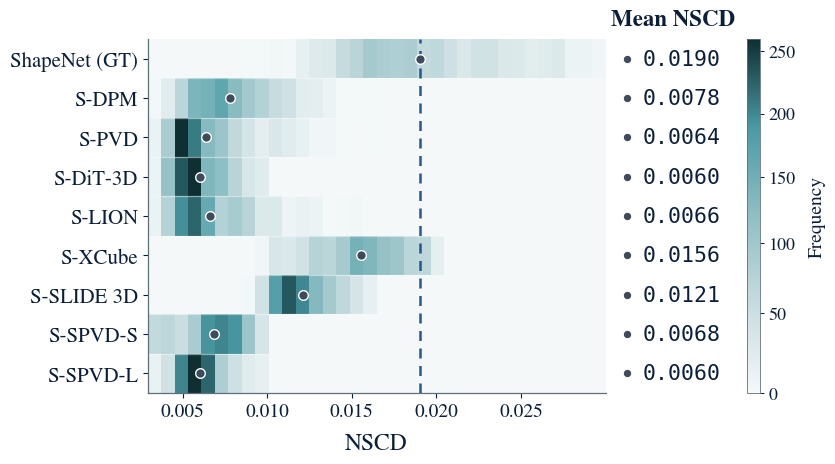

(array([[  0,   0,   0,   0,   0,   0,   0,   1,   1,   3,   2,  15,  25,
          29,  57,  72,  95,  87,  84,  88,  60,  65,  47,  31,  42,  43,
          31,  29,  21,  24,  28,   8,   8,   4],
        [  2,  23,  70, 139, 146, 167, 126,  97,  78,  56,  45,  20,  18,
           9,   1,   1,   1,   1,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0],
        [ 11,  90, 261, 209, 129, 106,  62,  37,  18,  32,  22,  13,   4,
           4,   1,   0,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0],
        [  9, 114, 232, 259, 134, 121,  73,  34,  24,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0],
        [ 11,  76, 196, 224, 161,  78,  92,  73,  28,  28,   7,  12,   8,
           0,   2,   3,   0,   1,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0],
        [ 

In [135]:
results = {
    "ShapeNet (GT)": shapenet1000_chair_data,
    #"DPM": dpm_chair_data,
    "S-DPM": s_dpm_chair_data,
    #"PVD": pvd1000_chair_data,
    "S-PVD": s_pvd_chair_data,
    #"DiT-3D": dit_3d_chair_data,
    "S-DiT-3D": s_dit_3d_chair_data,
    #"LION": lion250_chair_data,
    "S-LION": s_lion_chair_data,
    #"XCube": xcube1000_chair_data,
    "S-XCube": s_xcube_chair_data,
    #"SLIDE 3D": slide1000_chair_data,
    "S-SLIDE 3D": s_slide_chair_data,
    #"SPVD-S": spvd_s_chair_data,
    "S-SPVD-S": s_spvd_s_chair_data,
    #"SPVD-L": spvd_l_chair_data,
    "S-SPVD-L": s_spvd_l_chair_data
}

models = list(results.keys())
title = "Symmetry Evaluation Across 3D Generative Models - Chair Class"
output_path = "s-symmetry_chair.pdf"

generate_heatmap_and_save(results, models, title, output_path)